In [6]:
# Importing the libraries
import numpy as np
import pandas as pd
import time

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from scipy import stats
from scipy.stats import norm, skew
from scipy.special import boxcox1p
from scipy.stats import boxcox_normmax

from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

import sklearn
from sklearn import metrics
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import average_precision_score, precision_recall_curve

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.ensemble import AdaBoostClassifier

In [7]:
# Mounting the google drive
from google.colab import drive
drive.mount('/content/gdrive')


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [8]:
df_original = pd.read_csv('gdrive/My Drive/Colab Notebooks/creditcard.csv')
df_original.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
print(df_original.shape)
print(df_original['Class'].value_counts())

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


In [10]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [11]:
df, _ = train_test_split(
    df_original,
    test_size=2/3,
    stratify=df_original['Class'],
    random_state=42
)

In [12]:
print(df.shape)
print(df['Class'].value_counts())

(94935, 31)
Class
0    94771
1      164
Name: count, dtype: int64


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94935 entries, 188478 to 166477
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    94935 non-null  float64
 1   V1      94935 non-null  float64
 2   V2      94935 non-null  float64
 3   V3      94935 non-null  float64
 4   V4      94935 non-null  float64
 5   V5      94935 non-null  float64
 6   V6      94935 non-null  float64
 7   V7      94935 non-null  float64
 8   V8      94935 non-null  float64
 9   V9      94935 non-null  float64
 10  V10     94935 non-null  float64
 11  V11     94935 non-null  float64
 12  V12     94935 non-null  float64
 13  V13     94935 non-null  float64
 14  V14     94935 non-null  float64
 15  V15     94935 non-null  float64
 16  V16     94935 non-null  float64
 17  V17     94935 non-null  float64
 18  V18     94935 non-null  float64
 19  V19     94935 non-null  float64
 20  V20     94935 non-null  float64
 21  V21     94935 non-null  float64
 2

In [14]:
#Checking the numerical vales distribution in dataset
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,94935.000000,94935.000000,94935.000000,94935.000000,94935.000000,94935.000000,94935.000000,94935.000000,94935.000000,94935.000000,...,94935.000000,94935.000000,94935.000000,94935.000000,94935.000000,94935.000000,94935.000000,94935.000000,94935.000000,94935.000000
mean,94885.637763,0.005059,-0.000489,-0.001386,0.003540,0.000413,-0.001387,-0.006138,-0.000773,0.007923,...,-0.003112,-0.000207,0.001417,-0.001226,-0.002962,0.000701,0.001985,0.000281,87.705754,0.001727
std,47461.300798,1.956931,1.641427,1.521821,1.413096,1.402829,1.340426,1.273566,1.215563,1.102125,...,0.747999,0.725728,0.613745,0.605736,0.520936,0.482237,0.408075,0.302448,250.262871,0.041527
min,0.000000,-46.855047,-60.464618,-48.325589,-5.560118,-113.743307,-21.929312,-43.557242,-73.216718,-13.320155,...,-34.830382,-9.499423,-30.269720,-2.836627,-7.081325,-2.604551,-9.543518,-15.430084,0.000000,0.000000
25%,54270.500000,-0.914729,-0.599880,-0.894287,-0.839876,-0.693145,-0.766379,-0.554741,-0.206575,-0.638584,...,-0.228897,-0.546144,-0.161371,-0.357042,-0.318071,-0.327100,-0.070220,-0.052617,5.760000,0.000000
50%,84836.000000,0.026071,0.062236,0.182339,-0.018222,-0.054905,-0.274651,0.039178,0.023457,-0.044544,...,-0.029886,0.005033,-0.010238,0.040768,0.015053,-0.050637,0.001627,0.011343,22.080000,0.000000
75%,139311.000000,1.315448,0.804081,1.023565,0.745349,0.611858,0.391842,0.570021,0.325334,0.607722,...,0.184047,0.524395,0.148588,0.437835,0.346683,0.240843,0.091964,0.078148,77.000000,0.000000
max,172792.000000,2.446505,22.057729,4.101716,16.875344,32.911462,73.301626,120.589494,20.007208,10.370658,...,27.202839,10.503090,22.083545,4.584549,6.070850,3.517346,31.612198,15.870474,25691.160000,1.000000


In [15]:
#Checking class distribution of Target Variable -- Class
df['Class'].value_counts()

,count
Class,
0,94771
1,164


Class
0    99.82725
1     0.17275
Name: Class, dtype: float64


<Axes: ylabel='Class'>

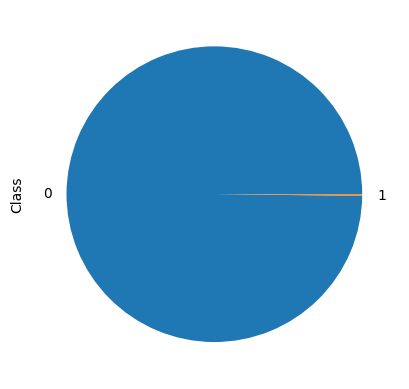

In [16]:
#Checking In %
print((df.groupby('Class')['Class'].count()/df['Class'].count())*100)
((df.groupby('Class')['Class'].count()/df['Class'].count())*100).plot.pie()

In [17]:
# Checking the % distribution of normal vs fraud
classes=df['Class'].value_counts()
normal_share=classes[0]/df['Class'].count()*100
fraud_share=classes[1]/df['Class'].count()*100

print(normal_share)
print(fraud_share)

99.82725022383735
0.1727497761626376


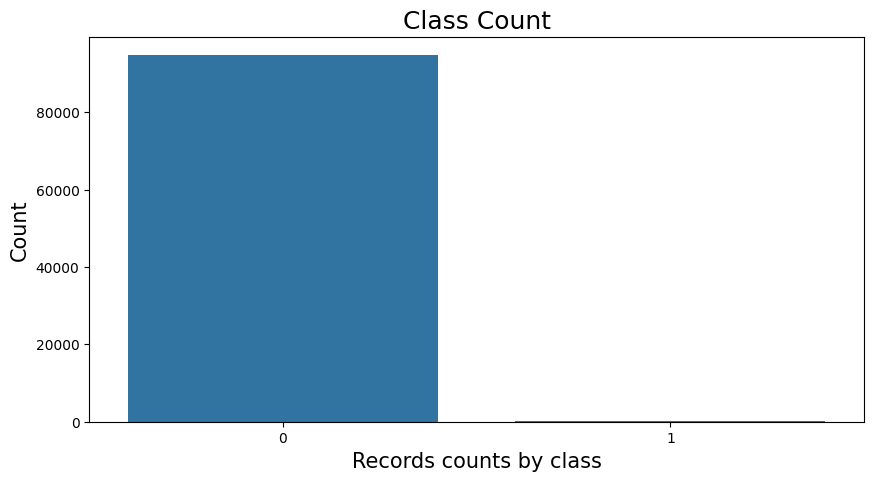

In [18]:
#Bar Plot -- Fraudant vs Non fraudant in %
plt.figure(figsize=(10,5))
sns.countplot(x='Class',data=df)
plt.title('Class Count', fontsize=18)
plt.xlabel('Records counts by class', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.show()

In [19]:
# Checking Correlation
corr = df.corr()
corr

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,0.113642,-0.010984,-0.417530,-0.105121,0.172592,-0.064923,0.086314,-0.037322,-0.008504,...,0.040891,0.142937,0.054889,-0.015770,-0.235184,-0.038048,-0.004796,-0.012257,-0.009393,-0.013851
V1,0.113642,1.000000,-0.011421,0.002536,0.001408,0.000055,-0.004036,0.006222,0.013546,0.001229,...,0.024578,-0.008737,-0.009869,0.001746,0.002219,-0.000774,-0.020073,0.036906,-0.219569,-0.110801
V2,-0.010984,-0.011421,1.000000,-0.010343,-0.000311,-0.005936,-0.000550,-0.004437,-0.010705,-0.003248,...,-0.000393,-0.008156,-0.005410,0.000336,-0.000863,-0.000013,-0.018344,0.055775,-0.511381,0.100516
V3,-0.417530,0.002536,-0.010343,1.000000,-0.005220,0.011703,-0.010739,-0.005285,0.016652,0.003605,...,0.018892,-0.009417,0.000257,-0.001104,0.003227,-0.006049,-0.015351,0.023171,-0.215821,-0.208842
V4,-0.105121,0.001408,-0.000311,-0.005220,1.000000,-0.002360,0.005451,0.002082,-0.004682,-0.002730,...,-0.009009,0.007178,0.000785,0.000168,0.002021,-0.002257,0.007932,-0.023309,0.099040,0.134807
V5,0.172592,0.000055,-0.005936,0.011703,-0.002360,1.000000,-0.025578,-0.029907,0.019154,0.001029,...,0.029222,-0.008140,0.022389,-0.005796,-0.003708,-0.006008,-0.038202,0.021382,-0.411825,-0.113465
V6,-0.064923,-0.004036,-0.000550,-0.010739,0.005451,-0.025578,1.000000,0.018390,-0.017281,0.005351,...,-0.025170,0.008451,-0.013375,0.002653,0.003266,0.005261,0.030373,-0.012969,0.239253,-0.043056
V7,0.086314,0.006222,-0.004437,-0.005285,0.002082,-0.029907,0.018390,1.000000,0.008911,0.003213,...,0.002152,-0.002869,-0.035852,0.006247,-0.002317,-0.001486,0.060056,-0.029660,0.419801,-0.203352
V8,-0.037322,0.013546,-0.010705,0.016652,-0.004682,0.019154,-0.017281,0.008911,1.000000,0.011673,...,0.062720,-0.020786,-0.005622,0.000065,0.008703,-0.002904,-0.008401,0.014984,-0.114520,0.033474
V9,-0.008504,0.001229,-0.003248,0.003605,-0.002730,0.001029,0.005351,0.003213,0.011673,1.000000,...,0.011476,-0.002179,0.001308,0.001360,0.001365,-0.002393,0.006483,-0.000584,-0.040589,-0.105897


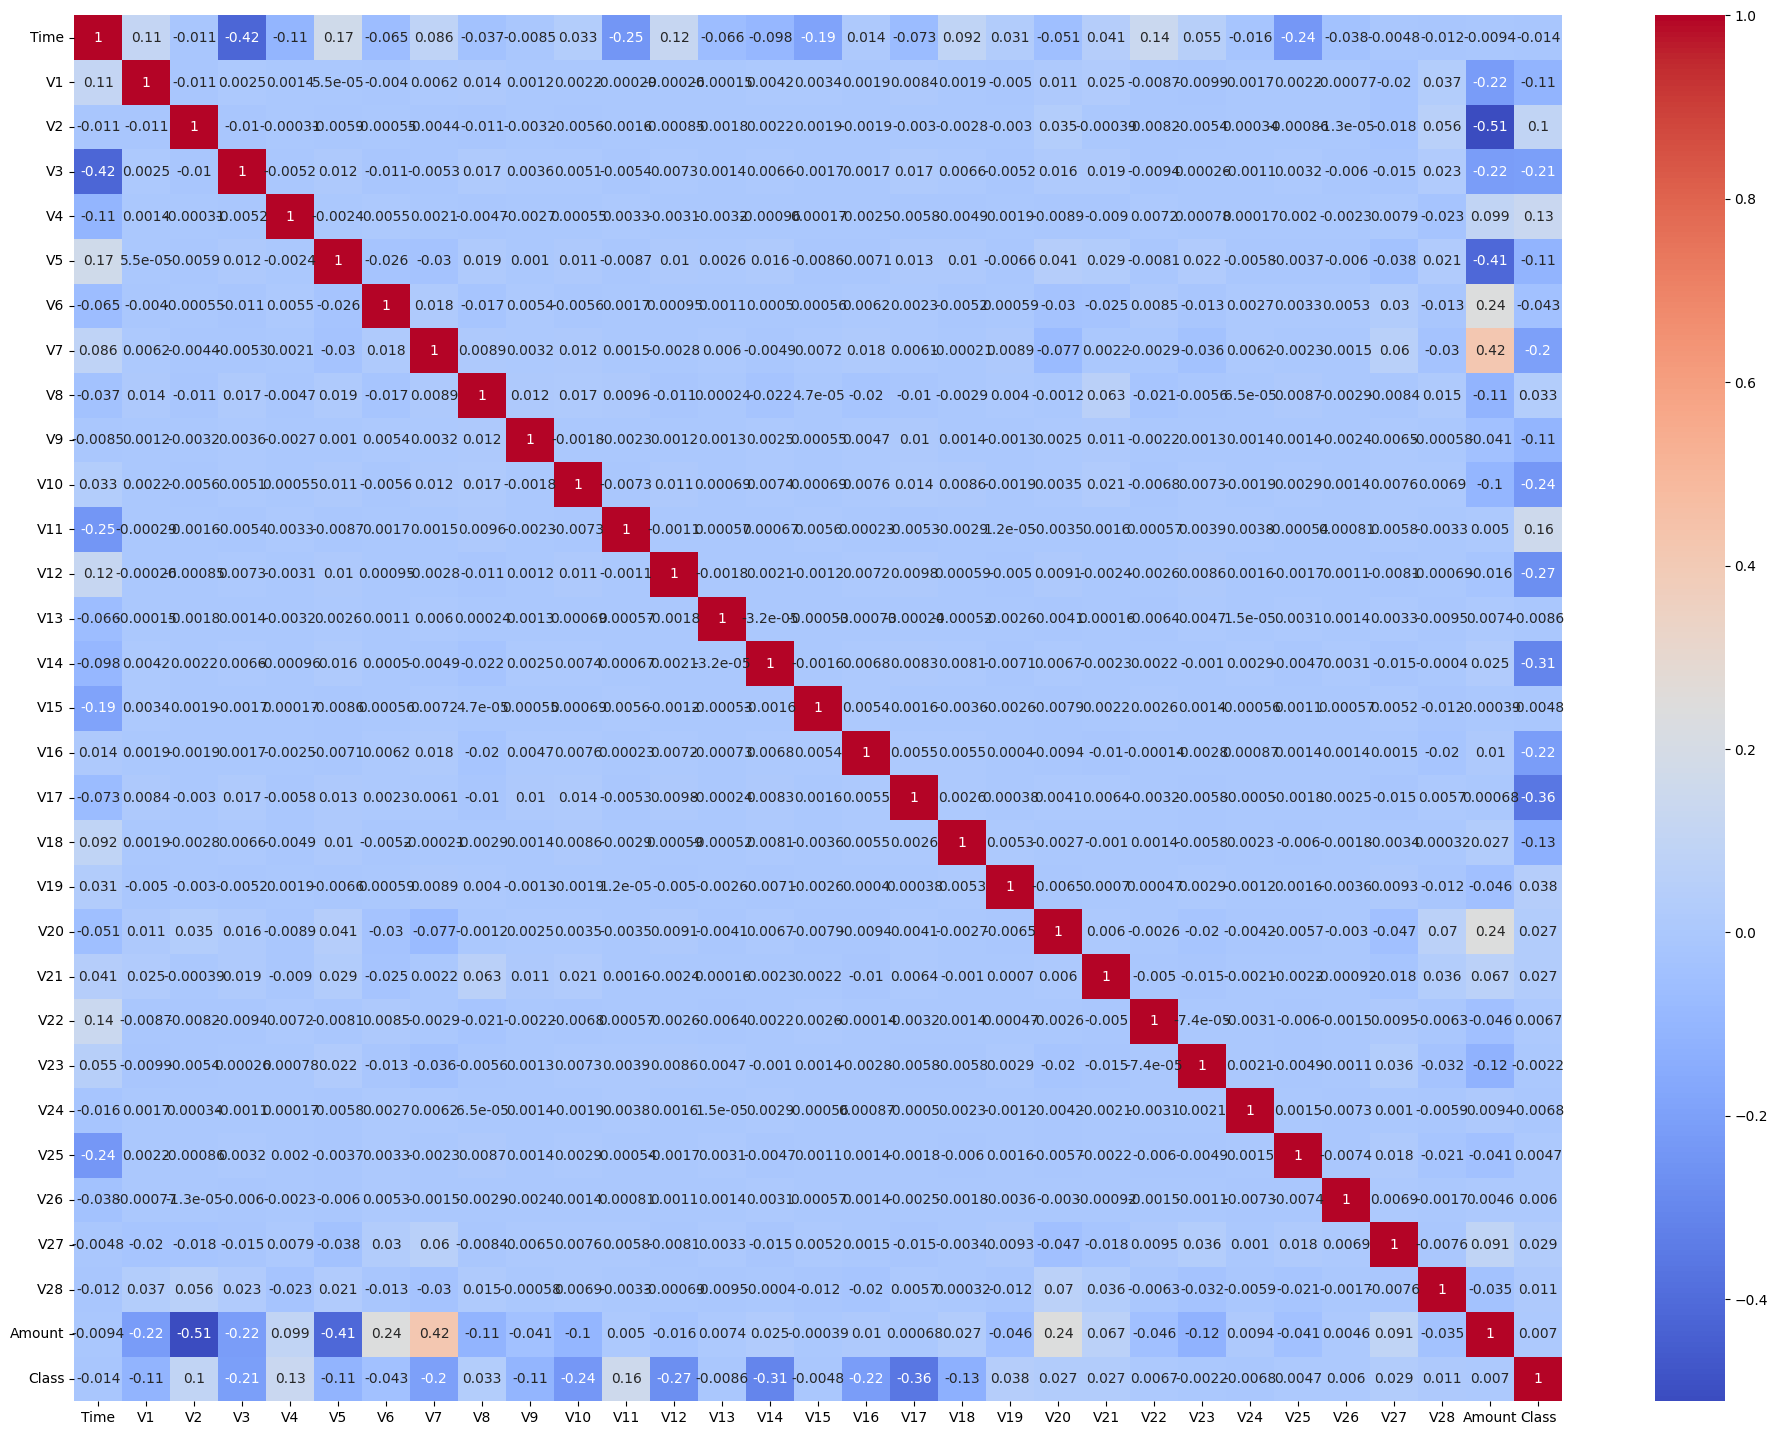

In [20]:
#Checking correlation in Heatmap
plt.figure(figsize=(24,18))
sns.heatmap(corr, cmap="coolwarm" ,annot=True)
plt.show()

*Observing the distribution of our classes*

In [21]:
# As the time is given in relative fashion, we are using pandas. Timedelta which represents a duration, the difference between two time
Delta_Time= pd.to_timedelta(df['Time'], unit='s')

#Create derived columns Mins and hours
df['Time_Day']=(Delta_Time.dt.components.days).astype(int)
df['Time_Hour']=(Delta_Time.dt.components.hours).astype(int)
df['Time_Min']=(Delta_Time.dt.components.minutes).astype(int)

In [22]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Class,Time_Day,Time_Hour,Time_Min
188478,127992.0,2.058216,-0.341962,-0.634181,0.274131,-0.222164,-0.003679,-0.555059,-0.056974,1.382131,...,-0.949786,0.079003,-0.153748,0.048212,-0.045393,4.99,0,1,11,33
263635,161047.0,-0.748441,-0.028152,-1.323703,-1.585628,3.239617,3.186924,0.225115,0.842438,0.022219,...,0.680535,-0.343131,0.160997,0.065699,0.089806,3.66,0,1,20,44
27031,34357.0,1.217223,-0.608400,0.425112,-0.724341,-1.041434,-0.574107,-0.533478,0.040667,2.150632,...,-0.108651,0.768519,-0.479187,0.070081,0.024537,37.88,0,0,9,32
271125,164422.0,-2.545293,-4.147554,-2.627830,-0.377596,-4.029510,1.214627,7.376324,-1.135144,-0.471305,...,-0.112468,-0.763421,0.202557,-0.542457,0.202153,1728.00,0,1,21,40
137445,82161.0,-1.444886,0.278894,1.662898,-1.608784,-1.032950,0.206885,-0.414777,0.464105,-0.196466,...,0.138209,-0.059512,-0.177080,-0.007924,-0.037093,38.85,0,0,22,49


In [23]:
# Drop unnecessary columns
# We wiLl drop Time, as we have derived the Day/Hour/Minutes from the time column
df.drop('Time', axis = 1, inplace= True)
# We will keep only derived column hour, as day/minutes might not be very useful
df.drop(['Time_Day', 'Time_Min'], axis = 1, inplace= True)

In [24]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Time_Hour
188478,2.058216,-0.341962,-0.634181,0.274131,-0.222164,-0.003679,-0.555059,-0.056974,1.382131,-0.192435,...,0.716194,-0.017505,-0.949786,0.079003,-0.153748,0.048212,-0.045393,4.99,0,11
263635,-0.748441,-0.028152,-1.323703,-1.585628,3.239617,3.186924,0.225115,0.842438,0.022219,-0.130291,...,-0.659428,0.637870,0.680535,-0.343131,0.160997,0.065699,0.089806,3.66,0,20
27031,1.217223,-0.608400,0.425112,-0.724341,-1.041434,-0.574107,-0.533478,0.040667,2.150632,-1.081240,...,0.395759,-0.253725,-0.108651,0.768519,-0.479187,0.070081,0.024537,37.88,0,9
271125,-2.545293,-4.147554,-2.627830,-0.377596,-4.029510,1.214627,7.376324,-1.135144,-0.471305,-2.006820,...,1.165893,4.056134,-0.112468,-0.763421,0.202557,-0.542457,0.202153,1728.00,0,21
137445,-1.444886,0.278894,1.662898,-1.608784,-1.032950,0.206885,-0.414777,0.464105,-0.196466,0.425362,...,1.410107,-0.089830,0.138209,-0.059512,-0.177080,-0.007924,-0.037093,38.85,0,22


**Splitting the Data into Train & Test Data**

In [25]:
df = df.reset_index(drop=True)

In [26]:
# Splitting the dataset into X and y
y= df['Class']
X = df.drop(['Class'], axis=1)

In [27]:
#Checking rows of x
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Time_Hour
0,2.058216,-0.341962,-0.634181,0.274131,-0.222164,-0.003679,-0.555059,-0.056974,1.382131,-0.192435,...,0.134774,0.716194,-0.017505,-0.949786,0.079003,-0.153748,0.048212,-0.045393,4.99,11
1,-0.748441,-0.028152,-1.323703,-1.585628,3.239617,3.186924,0.225115,0.842438,0.022219,-0.130291,...,-0.303000,-0.659428,0.637870,0.680535,-0.343131,0.160997,0.065699,0.089806,3.66,20
2,1.217223,-0.608400,0.425112,-0.724341,-1.041434,-0.574107,-0.533478,0.040667,2.150632,-1.081240,...,0.071793,0.395759,-0.253725,-0.108651,0.768519,-0.479187,0.070081,0.024537,37.88,9
3,-2.545293,-4.147554,-2.627830,-0.377596,-4.029510,1.214627,7.376324,-1.135144,-0.471305,-2.006820,...,1.385819,1.165893,4.056134,-0.112468,-0.763421,0.202557,-0.542457,0.202153,1728.00,21
4,-1.444886,0.278894,1.662898,-1.608784,-1.032950,0.206885,-0.414777,0.464105,-0.196466,0.425362,...,0.360434,1.410107,-0.089830,0.138209,-0.059512,-0.177080,-0.007924,-0.037093,38.85,22


In [28]:
#Checking rows of y
y.head()

,Class
0,0
1,0
2,0
3,0
4,0


In [29]:
# Splitting the dataset using train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=100, test_size=0.20)

In [30]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
print(X_train.mean(axis=0))
print(X_train.std(axis=0))

[ 2.66635961e-18 -4.72460212e-18 -3.67209174e-18  2.17051028e-17
  1.63723836e-18 -2.05824251e-18  1.15074467e-17  4.67782388e-18
  1.01976561e-17  1.49690364e-18 -2.46053536e-17  3.92937206e-18
  1.99275297e-17 -7.78857676e-18  2.46989101e-17 -7.67163116e-18
 -1.28172374e-17  1.09461079e-17 -2.78330521e-18 -4.39715445e-18
 -5.23916274e-18  1.00105431e-17  9.35564776e-19  2.38569018e-18
  8.32652650e-18  1.16010032e-17 -2.15179898e-18  1.49690364e-18
  4.32230926e-17  9.63631719e-17]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


In [32]:
#Checking spread of data post split
print(np.sum(y))
print(np.sum(y_train))
print(np.sum(y_test))

164
121
43


**Ploting the distribution of a Variable**

In [33]:
# Accumulating all the column names under one variable
cols = list(X.columns.values)

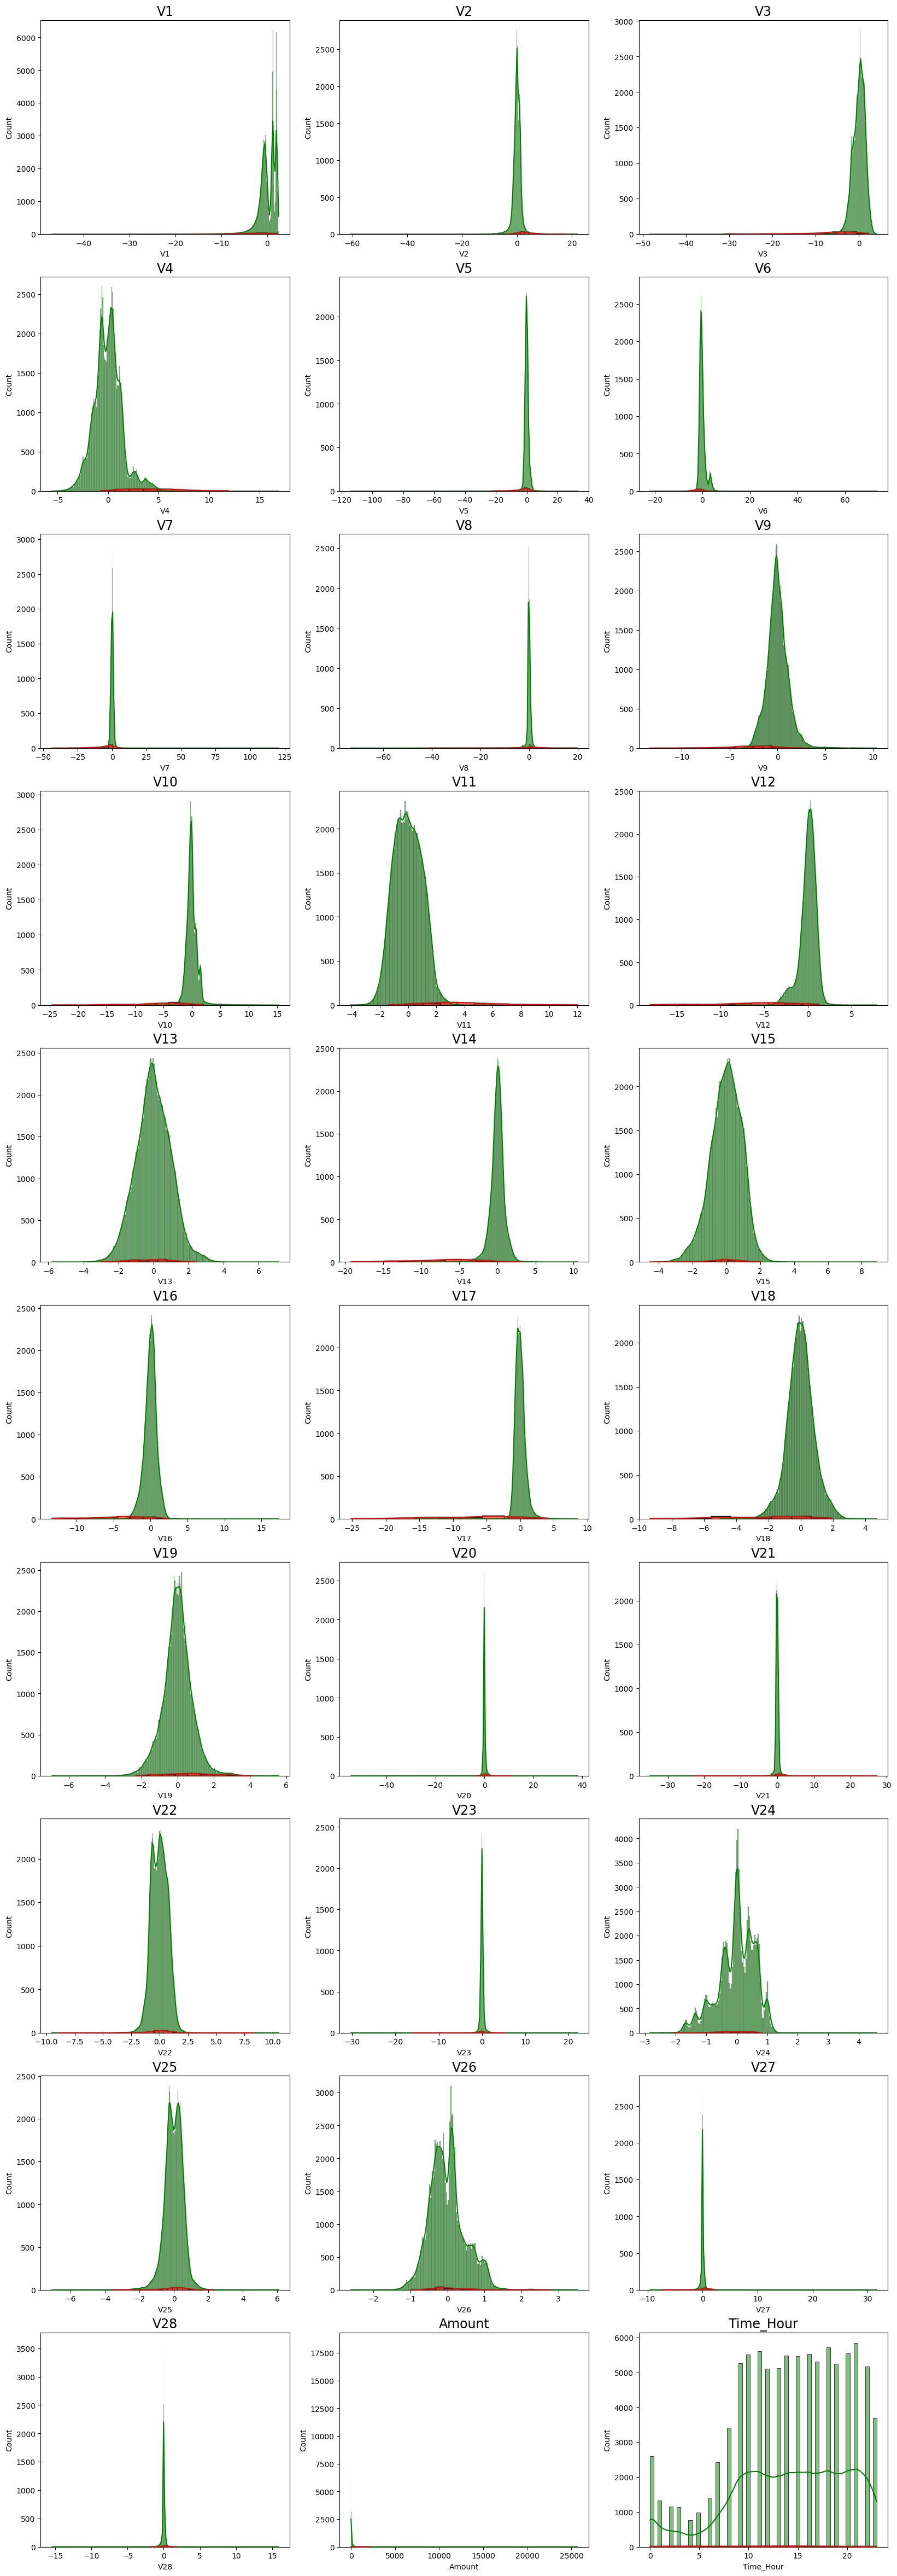

In [34]:
# Plot the histogram of a variable from the dataset to see the skewness
normal_records = df.Class == 0
fraud_records = df.Class == 1
plt.figure(figsize=(20, 60))

for n, col in enumerate(cols):
    plt.subplot(10, 3, n + 1)
    sns.histplot(X[col][normal_records], color='green', kde=True)
    sns.histplot(X[col][fraud_records], color='red', kde=True)
    plt.title(col, fontsize=17)

plt.show()

**Model Building**

In [35]:
#Create a dataframe to store results
df_Results = pd.DataFrame(columns=['Methodology','Model', 'Accuracy', 'roc_value', 'threshold'])


In [36]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Time_Hour
0,2.058216,-0.341962,-0.634181,0.274131,-0.222164,-0.003679,-0.555059,-0.056974,1.382131,-0.192435,...,0.716194,-0.017505,-0.949786,0.079003,-0.153748,0.048212,-0.045393,4.99,0,11
1,-0.748441,-0.028152,-1.323703,-1.585628,3.239617,3.186924,0.225115,0.842438,0.022219,-0.130291,...,-0.659428,0.637870,0.680535,-0.343131,0.160997,0.065699,0.089806,3.66,0,20
2,1.217223,-0.608400,0.425112,-0.724341,-1.041434,-0.574107,-0.533478,0.040667,2.150632,-1.081240,...,0.395759,-0.253725,-0.108651,0.768519,-0.479187,0.070081,0.024537,37.88,0,9
3,-2.545293,-4.147554,-2.627830,-0.377596,-4.029510,1.214627,7.376324,-1.135144,-0.471305,-2.006820,...,1.165893,4.056134,-0.112468,-0.763421,0.202557,-0.542457,0.202153,1728.00,0,21
4,-1.444886,0.278894,1.662898,-1.608784,-1.032950,0.206885,-0.414777,0.464105,-0.196466,0.425362,...,1.410107,-0.089830,0.138209,-0.059512,-0.177080,-0.007924,-0.037093,38.85,0,22


In [37]:
# Created a common function to plot confusion matrix
def Plot_confusion_matrix(y_test, pred_test):
  cm = confusion_matrix(y_test, pred_test, labels=[0,1])
  plt.clf()
  plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Accent)
  categoryNames = ['Non-Fraudulent', 'Fraudulent' ]
  plt.title('Confusion Matrix - Test Data')
  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  ticks = np.arange(len(categoryNames))
  plt.xticks(ticks, categoryNames, rotation=45)
  plt.yticks(ticks, categoryNames)
  s = [['TN','FP'], ['FN', 'TP']]

  for i in range(2):
    for j in range(2):
      plt.text(j,i, str(s[i][j])+" = "+str(cm[i][j]),fontsize=12)
  plt.show()

In [38]:
def buildAndRunLogisticModels(df_Results, Methodology, X_train, y_train, X_test, y_test):

    from sklearn import linear_model
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import (
        accuracy_score,
        classification_report,
        precision_score,
        recall_score,
        f1_score,
        roc_auc_score,
        roc_curve,
        auc
    )

    # C values for hyperparameter tuning
    num_C = list(np.power(10.0, np.arange(-5, 5)))

    # Stratified cross validation
    cv_num = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # Logistic Regression with L2 regularisation
    searchCV_l2 = linear_model.LogisticRegressionCV(
        Cs=num_C,
        penalty='l2',
        scoring='roc_auc',
        cv=cv_num,
        random_state=42,
        max_iter=5000,
        solver='newton-cg',
        tol=1e-4
    )

    # Logistic Regression with L1 regularisation
    searchCV_l1 = linear_model.LogisticRegressionCV(
        Cs=num_C,
        penalty='l1',
        scoring='roc_auc',
        cv=cv_num,
        random_state=42,
        max_iter=5000,
        solver='liblinear',
        tol=1e-4
    )

    # Train the models
    print("Training L1 Logistic Regression...")
    searchCV_l1.fit(X_train, y_train)

    print("Training L2 Logistic Regression...")
    searchCV_l2.fit(X_train, y_train)

    # Check the best C value selected by cross validation
    print("\nBest C for L1:", searchCV_l1.C_)
    print("Best C for L2:", searchCV_l2.C_)

    # Run predictions for both models
    for model, name in [(searchCV_l1, "L1"), (searchCV_l2, "L2")]:

        print(f"\nLogistic Regression - {name}")

        y_pred = model.predict(X_test)
        y_pred_probs = model.predict_proba(X_test)[:, 1]

        # Accuracy
        accuracy = accuracy_score(y_test, y_pred)
        print("\nAccuracy:", accuracy)

        # Precision, Recall and F1 Score
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        print("Precision:", precision)
        print("Recall:", recall)
        print("F1 Score:", f1)

        # Confusion matrix
        print("\nConfusion Matrix")
        Plot_confusion_matrix(y_test, y_pred)

        # Classification report
        print("\nClassification Report")
        print(classification_report(y_test, y_pred))

        # Calculate ROC-AUC
        roc_value = roc_auc_score(y_test, y_pred_probs)
        print("ROC-AUC:", roc_value)

        # Calculate ROC curve
        fpr, tpr, thresholds = roc_curve(
            y_test,
            y_pred_probs
        )

        # Find the threshold using Youden's J statistic
        threshold = thresholds[np.argmax(tpr - fpr)]
        print("Best Threshold:", threshold)

        roc_auc = auc(fpr, tpr)

        print(
            "ROC for the test dataset:",
            '{:.1%}'.format(roc_auc)
        )

        # Plot ROC curve
        plt.figure(figsize=(6, 5))
        plt.plot(
            fpr,
            tpr,
            label="Test, AUC=" + str(round(roc_auc, 4))
        )

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - Logistic Regression {name}")
        plt.legend(loc=4)
        plt.show()

        # Save the model results
        df_Results = pd.concat(
            [
                df_Results,
                pd.DataFrame([{
                    'Methodology': Methodology,
                    'Model': f'Logistic Regression with {name} Regularisation',
                    'Accuracy': accuracy,
                    'Precision': precision,
                    'Recall': recall,
                    'F1': f1,
                    'roc_value': roc_value,
                    'threshold': threshold
                }])
            ],
            ignore_index=True
        )

    return df_Results

In [39]:
# Created a common function to fit and predict on a KNN model
def buildAndRunKNNModels(df_Results, Methodology, X_train, y_train, X_test, y_test):

  # Create KNN model and fit the model with train dataset
  knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
  knn.fit(X_train, y_train)
  score = knn.score(X_test, y_test)
  print("Model score")
  print(score)

  # Accuracy
  y_pred = knn.predict(X_test)
  KNN_Accuracy = metrics.accuracy_score(y_pred=y_pred, y_true=y_test)

  # Precision, Recall and F1 Score
  KNN_Precision = metrics.precision_score(y_test, y_pred, zero_division=0)
  KNN_Recall = metrics.recall_score(y_test, y_pred, zero_division=0)
  KNN_F1 = metrics.f1_score(y_test, y_pred, zero_division=0)

  print("Confusion Matrix")
  Plot_confusion_matrix(y_test, y_pred)
  print("Classification Report")
  print(classification_report(y_test, y_pred))

  knn_probs = knn.predict_proba(X_test)[:, 1]

  # Calculate ROC AUC
  knn_roc_value = roc_auc_score(y_test, knn_probs)
  print("KNN roc_value: {0}".format(knn_roc_value))
  fpr, tpr, thresholds = metrics.roc_curve(y_test, knn_probs)
  threshold = thresholds[np.argmax(tpr - fpr)]
  print("KNN threshold: {0}".format(threshold))

  roc_auc = metrics.auc(fpr, tpr)
  print("ROC for the test dataset", '{:.1%}'.format(roc_auc))
  plt.plot(fpr, tpr, label="Test, auc=" + str(roc_auc))
  plt.legend(loc=4)
  plt.show()

  df_Results = pd.concat([
      df_Results,
    pd.DataFrame([{
      'Methodology': Methodology,
      'Model': 'KNN',
      'Accuracy': KNN_Accuracy,
      'Precision': KNN_Precision,
      'Recall': KNN_Recall,
      'F1': KNN_F1,
      'roc_value': knn_roc_value,
      'threshold': threshold
    }])
  ], ignore_index=True)

  return df_Results

In [40]:
# Created a common function to fit and predict on a Tree model for both gini and entropy criteria
def buildAndRunTreeModels(df_Results, Methodology, X_train, y_train, X_test, y_test):

  # Evaluate Decision Tree model with 'gini' & 'entropy'
  criteria = ['gini', 'entropy']
  scores = {}

  for c in criteria:
    dt = DecisionTreeClassifier(criterion=c, random_state=42)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)
    test_score = dt.score(X_test, y_test)

    # Precision, Recall and F1 Score
    tree_precision = metrics.precision_score(y_test, y_pred, zero_division=0)
    tree_recall = metrics.recall_score(y_test, y_pred, zero_division=0)
    tree_f1 = metrics.f1_score(y_test, y_pred, zero_division=0)

    tree_preds = dt.predict_proba(X_test)[:, 1]
    tree_roc_value = roc_auc_score(y_test, tree_preds)
    scores[c] = test_score

    print(c + " score: {0}".format(test_score))
    print("Precision: {0}".format(tree_precision))
    print("Recall: {0}".format(tree_recall))
    print("F1 Score: {0}".format(tree_f1))
    print("Confusion Matrix")
    Plot_confusion_matrix(y_test, y_pred)
    print("Classification Report")
    print(classification_report(y_test, y_pred))
    print(c + " tree_roc_value: {0}".format(tree_roc_value))

    fpr, tpr, thresholds = metrics.roc_curve(y_test, tree_preds)
    threshold = thresholds[np.argmax(tpr - fpr)]
    print("Tree threshold: {0}".format(threshold))

    roc_auc = metrics.auc(fpr, tpr)
    print("ROC for the test dataset", '{:.1%}'.format(roc_auc))
    plt.plot(fpr, tpr, label="Test, auc=" + str(roc_auc))
    plt.legend(loc=4)
    plt.show()

    df_Results = pd.concat([
      df_Results,
      pd.DataFrame([{
        'Methodology': Methodology,
        'Model': 'Tree Model with {0} criteria'.format(c),
        'Accuracy': test_score,
        'Precision': tree_precision,
        'Recall': tree_recall,
        'F1': tree_f1,
        'roc_value': tree_roc_value,
        'threshold': threshold
      }])
    ], ignore_index=True)

  return df_Results

In [41]:
# Created a common function to fit and predict on a Random Forest model
def buildAndRunRandomForestModels(df_Results, Methodology, X_train, y_train, X_test, y_test):

  # Evaluate Random Forest model

  # Create the model with 100 trees
  RF_model = RandomForestClassifier(
    n_estimators=100,
    bootstrap=True,
    max_features='sqrt',
    random_state=42
  )

  # Fit on training data
  RF_model.fit(X_train, y_train)
  RF_test_score = RF_model.score(X_test, y_test)

  print('Model Accuracy: {0}'.format(RF_test_score))

  # Actual class predictions
  rf_predictions = RF_model.predict(X_test)

  # Precision, Recall and F1 Score
  RF_Precision = metrics.precision_score(y_test, rf_predictions, zero_division=0)
  RF_Recall = metrics.recall_score(y_test, rf_predictions, zero_division=0)
  RF_F1 = metrics.f1_score(y_test, rf_predictions, zero_division=0)

  print("Precision:", RF_Precision)
  print("Recall:", RF_Recall)
  print("F1 Score:", RF_F1)

  print("Confusion Matrix")
  Plot_confusion_matrix(y_test, rf_predictions)
  print("Classification Report")
  print(classification_report(y_test, rf_predictions))

  # Probabilities for each class
  rf_probs = RF_model.predict_proba(X_test)[:, 1]

  # Calculate ROC AUC
  roc_value = roc_auc_score(y_test, rf_probs)

  print("Random Forest roc_value: {0}".format(roc_value))
  fpr, tpr, thresholds = metrics.roc_curve(y_test, rf_probs)
  threshold = thresholds[np.argmax(tpr - fpr)]
  print("Random Forest threshold: {0}".format(threshold))

  roc_auc = metrics.auc(fpr, tpr)
  print("ROC for the test dataset", '{:.1%}'.format(roc_auc))
  plt.plot(fpr, tpr, label="Test, auc=" + str(roc_auc))
  plt.legend(loc=4)
  plt.show()

  df_Results = pd.concat([
    df_Results,
    pd.DataFrame([{
      'Methodology': Methodology,
      'Model': 'Random Forest',
      'Accuracy': RF_test_score,
      'Precision': RF_Precision,
      'Recall': RF_Recall,
      'F1': RF_F1,
      'roc_value': roc_value,
      'threshold': threshold
    }])
  ], ignore_index=True)

  return df_Results

In [42]:
# Created a common function to fit and predict on an XGBoost model
def buildAndRunXGBoostModels(df_Results, Methodology, X_train, y_train, X_test, y_test):

  # Evaluate XGBoost model
  XGBmodel = XGBClassifier(random_state=42)
  XGBmodel.fit(X_train, y_train)
  y_pred = XGBmodel.predict(X_test)

  XGB_test_score = XGBmodel.score(X_test, y_test)
  print('Model Accuracy: {0}'.format(XGB_test_score))

  # Precision, Recall and F1 Score
  XGB_Precision = metrics.precision_score(y_test, y_pred, zero_division=0)
  XGB_Recall = metrics.recall_score(y_test, y_pred, zero_division=0)
  XGB_F1 = metrics.f1_score(y_test, y_pred, zero_division=0)

  print("Precision:", XGB_Precision)
  print("Recall:", XGB_Recall)
  print("F1 Score:", XGB_F1)

  print("Confusion Matrix")
  Plot_confusion_matrix(y_test, y_pred)
  print("Classification Report")
  print(classification_report(y_test, y_pred))

  # Probabilities for each class
  XGB_probs = XGBmodel.predict_proba(X_test)[:, 1]

  # Calculate ROC AUC
  XGB_roc_value = roc_auc_score(y_test, XGB_probs)

  print("XGBoost roc_value: {0}".format(XGB_roc_value))
  fpr, tpr, thresholds = metrics.roc_curve(y_test, XGB_probs)
  threshold = thresholds[np.argmax(tpr - fpr)]
  print("XGBoost threshold: {0}".format(threshold))

  roc_auc = metrics.auc(fpr, tpr)
  print("ROC for the test dataset", '{:.1%}'.format(roc_auc))
  plt.plot(fpr, tpr, label="Test, auc=" + str(roc_auc))
  plt.legend(loc=4)
  plt.show()

  df_Results = pd.concat([
    df_Results,
    pd.DataFrame([{
      'Methodology': Methodology,
      'Model': 'XGBoost',
      'Accuracy': XGB_test_score,
      'Precision': XGB_Precision,
      'Recall': XGB_Recall,
      'F1': XGB_F1,
      'roc_value': XGB_roc_value,
      'threshold': threshold
    }])
  ], ignore_index=True)

  return df_Results

In [43]:
# Created a common function to fit and predict on an SVM model
def buildAndRunSVMModels(df_Results, Methodology, X_train, y_train, X_test, y_test):

  # Evaluate SVM model with sigmoid kernel model
  from sklearn.svm import SVC
  from sklearn.metrics import accuracy_score
  from sklearn.metrics import roc_auc_score

  clf = SVC(kernel='sigmoid', probability=True, random_state=42)
  clf.fit(X_train, y_train)
  y_pred_SVM = clf.predict(X_test)

  SVM_Score = accuracy_score(y_test, y_pred_SVM)
  print("accuracy_score : {0}".format(SVM_Score))

  # Precision, Recall and F1 Score
  SVM_Precision = metrics.precision_score(y_test, y_pred_SVM, zero_division=0)
  SVM_Recall = metrics.recall_score(y_test, y_pred_SVM, zero_division=0)
  SVM_F1 = metrics.f1_score(y_test, y_pred_SVM, zero_division=0)

  print("Precision:", SVM_Precision)
  print("Recall:", SVM_Recall)
  print("F1 Score:", SVM_F1)

  print("Confusion Matrix")
  Plot_confusion_matrix(y_test, y_pred_SVM)

  print("Classification Report")
  print(classification_report(y_test, y_pred_SVM))

  # Probabilities for each class
  svm_probs = clf.predict_proba(X_test)[:, 1]

  # Calculate ROC AUC
  roc_value = roc_auc_score(y_test, svm_probs)

  print("SVM roc_value: {0}".format(roc_value))
  fpr, tpr, thresholds = metrics.roc_curve(y_test, svm_probs)
  threshold = thresholds[np.argmax(tpr - fpr)]
  print("SVM threshold: {0}".format(threshold))

  roc_auc = metrics.auc(fpr, tpr)
  print("ROC for the test dataset", '{:.1%}'.format(roc_auc))
  plt.plot(fpr, tpr, label="Test, auc=" + str(roc_auc))
  plt.legend(loc=4)
  plt.show()

  df_Results = pd.concat([
    df_Results,
    pd.DataFrame([{
      'Methodology': Methodology,
      'Model': 'SVM',
      'Accuracy': SVM_Score,
      'Precision': SVM_Precision,
      'Recall': SVM_Recall,
      'F1': SVM_F1,
      'roc_value': roc_value,
      'threshold': threshold
    }])
  ], ignore_index=True)

  return df_Results

**Perform Cross validation with RepeatedKFold**

In [44]:
# Let's perform RepeatedKFold and check the results
from sklearn.model_selection import RepeatedKFold

rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=None)

# X is the feature set and y is the target
for train_index, test_index in rkf.split(X, y):
    print("TRAIN:", train_index, "TEST:", test_index)

    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]


TRAIN: [    1     2     3 ... 94932 94933 94934] TEST: [    0     9    11 ... 94920 94921 94925]
TRAIN: [    0     1     2 ... 94932 94933 94934] TEST: [    5     8    16 ... 94923 94929 94930]
TRAIN: [    0     1     2 ... 94929 94930 94932] TEST: [   20    27    30 ... 94931 94933 94934]
TRAIN: [    0     2     4 ... 94932 94933 94934] TEST: [    1     3     6 ... 94908 94922 94928]
TRAIN: [    0     1     3 ... 94931 94933 94934] TEST: [    2     4     7 ... 94926 94927 94932]
TRAIN: [    0     3     5 ... 94932 94933 94934] TEST: [    1     2     4 ... 94924 94927 94930]
TRAIN: [    0     1     2 ... 94932 94933 94934] TEST: [    9    13    17 ... 94916 94919 94926]
TRAIN: [    1     2     4 ... 94929 94930 94932] TEST: [    0     3     5 ... 94931 94933 94934]
TRAIN: [    0     1     2 ... 94931 94933 94934] TEST: [   10    11    12 ... 94921 94923 94932]
TRAIN: [    0     1     2 ... 94932 94933 94934] TEST: [    7    14    25 ... 94918 94922 94929]
TRAIN: [    0     1     2 ... 

Logistic Regression with L1 And L2 Regularisation
Training L1 Logistic Regression...
Training L2 Logistic Regression...

Best C for L1: [1.]
Best C for L2: [0.001]

Logistic Regression - L1

Accuracy: 0.9993153210091115
Precision: 0.9230769230769231
Recall: 0.6857142857142857
F1 Score: 0.7868852459016393

Confusion Matrix


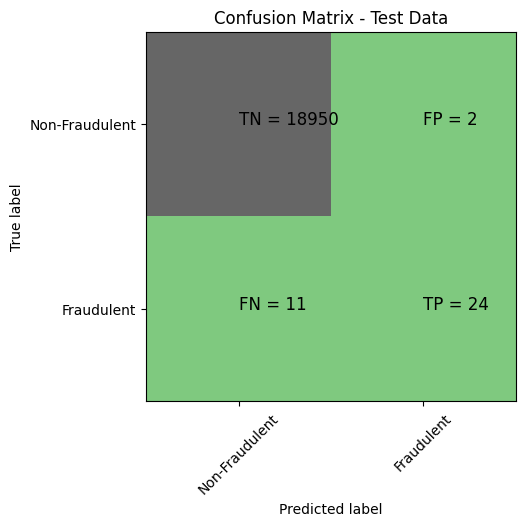


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18952
           1       0.92      0.69      0.79        35

    accuracy                           1.00     18987
   macro avg       0.96      0.84      0.89     18987
weighted avg       1.00      1.00      1.00     18987

ROC-AUC: 0.9585222818549115
Best Threshold: 0.004441660909803748
ROC for the test dataset: 95.9%


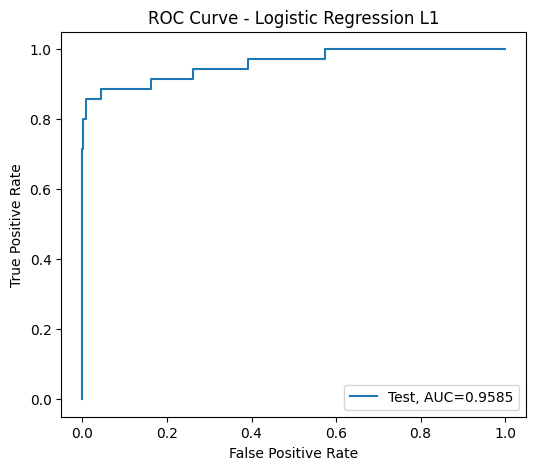


Logistic Regression - L2

Accuracy: 0.9989993153210092
Precision: 0.8636363636363636
Recall: 0.5428571428571428
F1 Score: 0.6666666666666666

Confusion Matrix


/tmp/ipykernel_940/2961874455.py:126: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_Results = pd.concat(


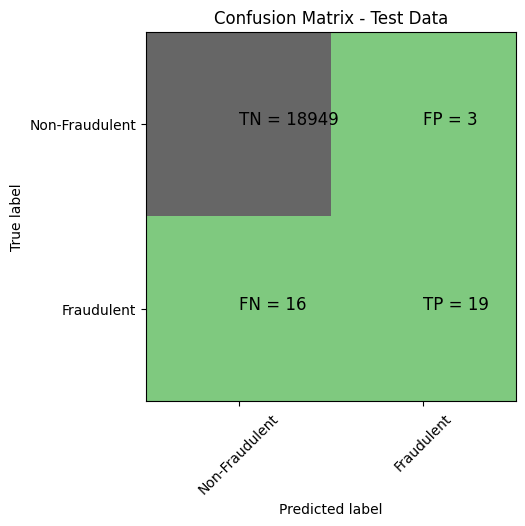


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18952
           1       0.86      0.54      0.67        35

    accuracy                           1.00     18987
   macro avg       0.93      0.77      0.83     18987
weighted avg       1.00      1.00      1.00     18987

ROC-AUC: 0.9795242115419406
Best Threshold: 0.0012376436029719177
ROC for the test dataset: 98.0%


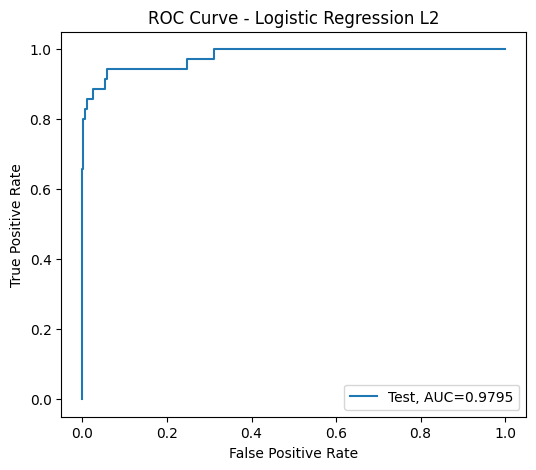

Time Taken by Model: --- 420.2230806350708 seconds --- 
------------------------------------------------------------
KNN Model
Model score
0.9990519829356929
Confusion Matrix


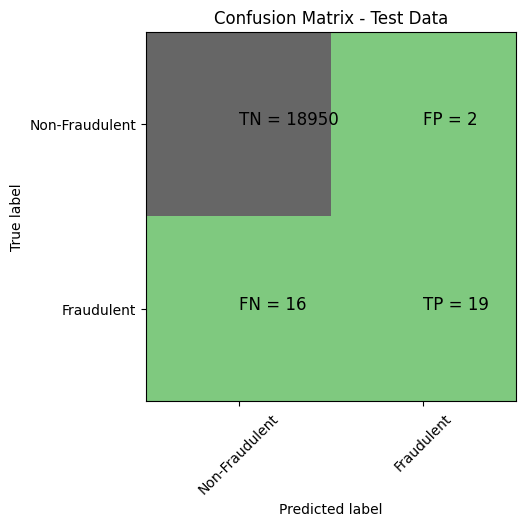

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18952
           1       0.90      0.54      0.68        35

    accuracy                           1.00     18987
   macro avg       0.95      0.77      0.84     18987
weighted avg       1.00      1.00      1.00     18987

KNN roc_value: 0.8712642465175179
KNN threshold: 0.2
ROC for the test dataset 87.1%


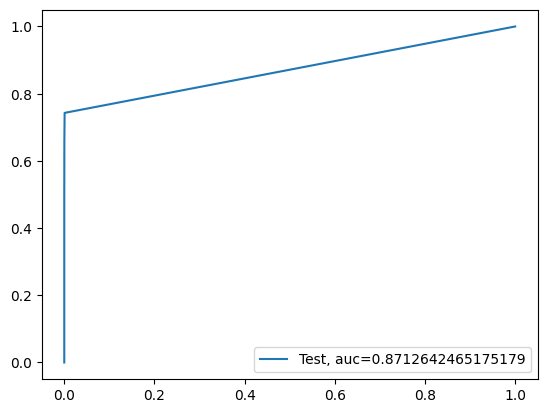

Time Taken by Model: --- 42.52656054496765 seconds --- 
------------------------------------------------------------
Decision Tree Models with 'gini' & 'entropy' criteria
gini score: 0.9991046505503766
Precision: 0.75
Recall: 0.7714285714285715
F1 Score: 0.7605633802816901
Confusion Matrix


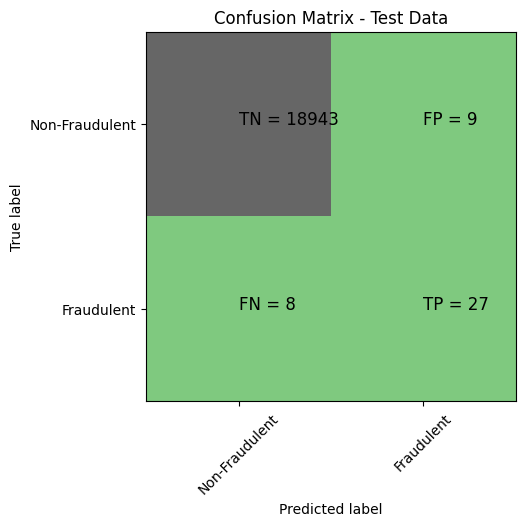

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18952
           1       0.75      0.77      0.76        35

    accuracy                           1.00     18987
   macro avg       0.87      0.89      0.88     18987
weighted avg       1.00      1.00      1.00     18987

gini tree_roc_value: 0.8854768437556534
Tree threshold: 1.0
ROC for the test dataset 88.5%


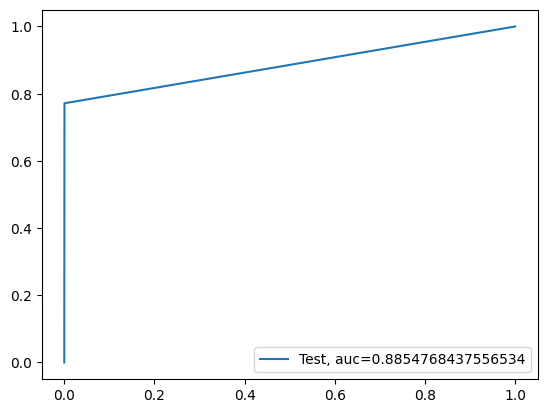

entropy score: 0.9992099857797441
Precision: 0.8333333333333334
Recall: 0.7142857142857143
F1 Score: 0.7692307692307693
Confusion Matrix


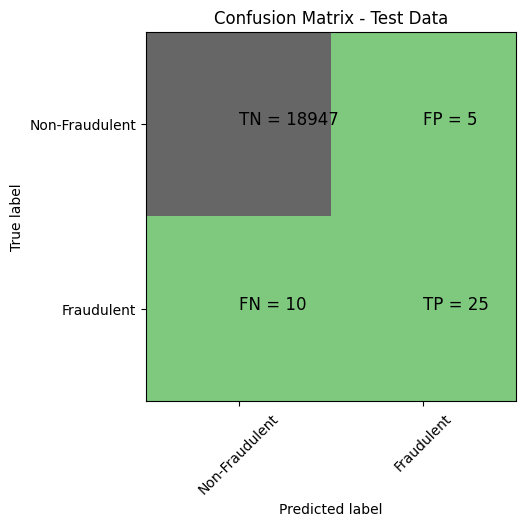

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18952
           1       0.83      0.71      0.77        35

    accuracy                           1.00     18987
   macro avg       0.92      0.86      0.88     18987
weighted avg       1.00      1.00      1.00     18987

entropy tree_roc_value: 0.857010944943617
Tree threshold: 1.0
ROC for the test dataset 85.7%


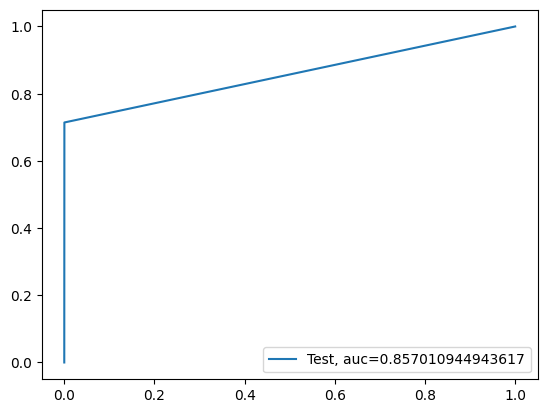

Time Taken by Model: --- 15.950079441070557 seconds --- 
------------------------------------------------------------
Random Forest Model
Model Accuracy: 0.9993153210091115
Precision: 0.8666666666666667
Recall: 0.7428571428571429
F1 Score: 0.8
Confusion Matrix


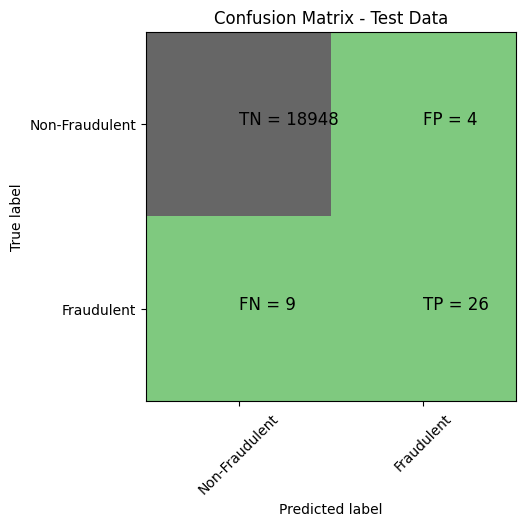

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18952
           1       0.87      0.74      0.80        35

    accuracy                           1.00     18987
   macro avg       0.93      0.87      0.90     18987
weighted avg       1.00      1.00      1.00     18987

Random Forest roc_value: 0.912004010130857
Random Forest threshold: 0.01
ROC for the test dataset 91.2%


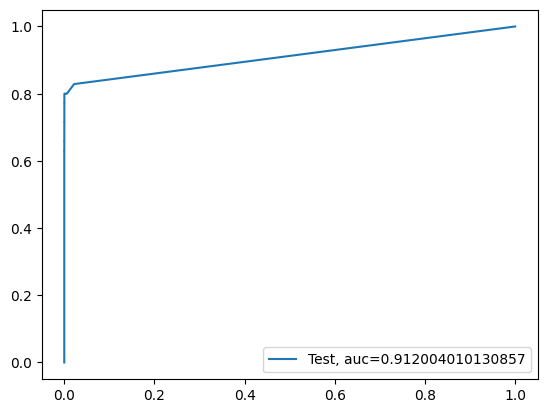

Time Taken by Model: --- 74.72101616859436 seconds --- 
------------------------------------------------------------
XGBoost Model
Model Accuracy: 0.9955759203665666
Precision: 0.0196078431372549
Recall: 0.02857142857142857
F1 Score: 0.023255813953488372
Confusion Matrix


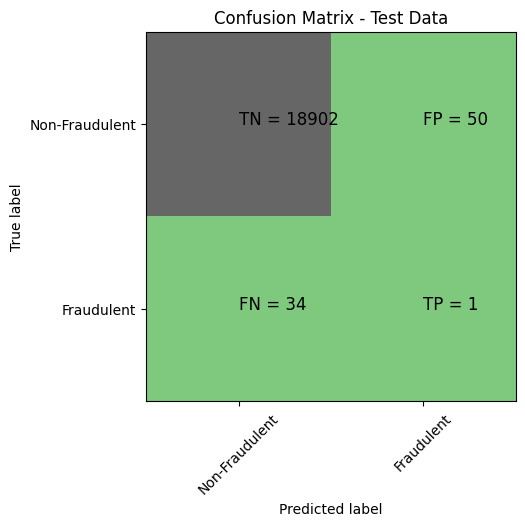

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18952
           1       0.02      0.03      0.02        35

    accuracy                           1.00     18987
   macro avg       0.51      0.51      0.51     18987
weighted avg       1.00      1.00      1.00     18987

XGBoost roc_value: 0.418295845142616
XGBoost threshold: 0.9999994039535522
ROC for the test dataset 41.8%


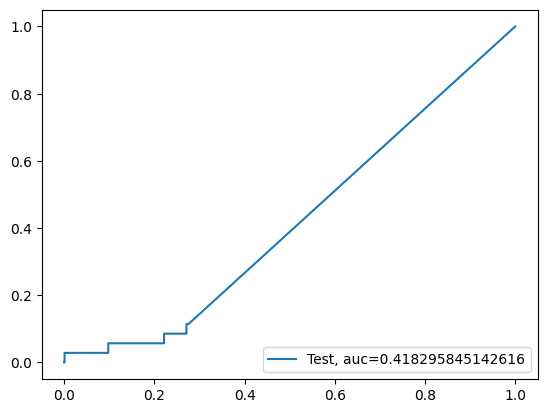

Time Taken by Model: --- 2.335026264190674 seconds --- 
------------------------------------------------------------
SVM Model with Sigmoid Kernel
accuracy_score : 0.9974719544951809
Precision: 0.06666666666666667
Recall: 0.02857142857142857
F1 Score: 0.04
Confusion Matrix


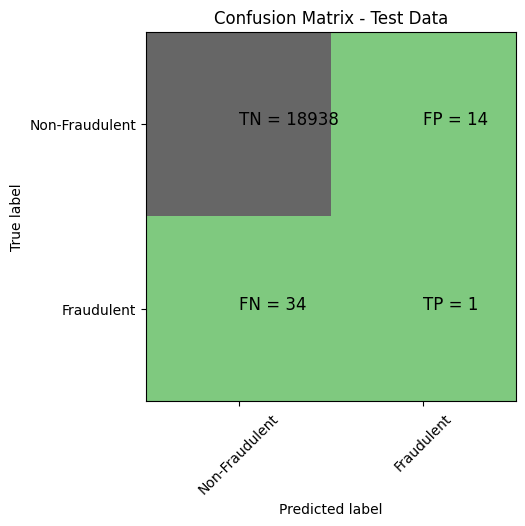

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18952
           1       0.07      0.03      0.04        35

    accuracy                           1.00     18987
   macro avg       0.53      0.51      0.52     18987
weighted avg       1.00      1.00      1.00     18987

SVM roc_value: 0.6686651993004884
SVM threshold: 0.001576045398337644
ROC for the test dataset 66.9%


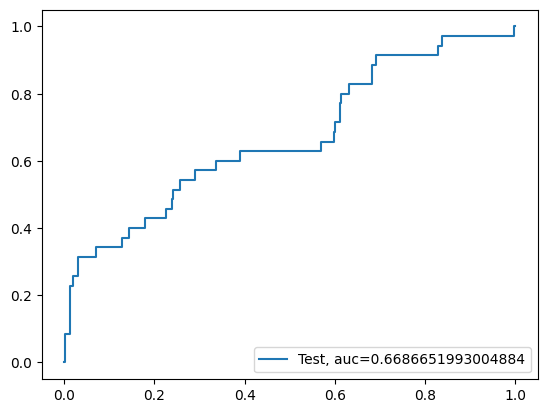

Time Taken by Model: --- 41.171412229537964 seconds --- 


In [45]:
# Run Logistic Regression with L1 And L2 Regularisation
print("Logistic Regression with L1 And L2 Regularisation")
start_time = time.time()
df_Results = buildAndRunLogisticModels(
    df_Results,
    "RepeatedKFold Cross Validation",
    X_train_cv, y_train_cv,
    X_test_cv, y_test_cv
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 60)


# Run KNN Model
print("KNN Model")
start_time = time.time()
df_Results = buildAndRunKNNModels(
    df_Results,
    "RepeatedKFold Cross Validation",
    X_train_cv, y_train_cv,
    X_test_cv, y_test_cv
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 60)


# Run Decision Tree Models with 'gini' & 'entropy' criteria
print("Decision Tree Models with 'gini' & 'entropy' criteria")
start_time = time.time()
df_Results = buildAndRunTreeModels(
    df_Results,
    "RepeatedKFold Cross Validation",
    X_train_cv, y_train_cv,
    X_test_cv, y_test_cv
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 60)


# Run Random Forest Model
print("Random Forest Model")
start_time = time.time()
df_Results = buildAndRunRandomForestModels(
    df_Results,
    "RepeatedKFold Cross Validation",
    X_train_cv, y_train_cv,
    X_test_cv, y_test_cv
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 60)


# Run XGBoost Model
print("XGBoost Model")
start_time = time.time()
df_Results = buildAndRunXGBoostModels(
    df_Results,
    "RepeatedKFold Cross Validation",
    X_train_cv, y_train_cv,
    X_test_cv, y_test_cv
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 60)


# Run SVM Model with Sigmoid Kernel
print("SVM Model with Sigmoid Kernel")
start_time = time.time()
df_Results = buildAndRunSVMModels(
    df_Results,
    "RepeatedKFold Cross Validation",
    X_train_cv, y_train_cv,
    X_test_cv, y_test_cv
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))


In [46]:
# Checking the df_result dataframe which contains consolidated results of all the runs
df_Results

,Methodology,Model,Accuracy,roc_value,threshold,Precision,Recall,F1
0,RepeatedKFold Cross Validation,Logistic Regression with L1 Regularisation,0.999315,0.958522,0.004442,0.923077,0.685714,0.786885
1,RepeatedKFold Cross Validation,Logistic Regression with L2 Regularisation,0.998999,0.979524,0.001238,0.863636,0.542857,0.666667
2,RepeatedKFold Cross Validation,KNN,0.999052,0.871264,0.200000,0.904762,0.542857,0.678571
3,RepeatedKFold Cross Validation,Tree Model with gini criteria,0.999105,0.885477,1.000000,0.750000,0.771429,0.760563
4,RepeatedKFold Cross Validation,Tree Model with entropy criteria,0.999210,0.857011,1.000000,0.833333,0.714286,0.769231
5,RepeatedKFold Cross Validation,Random Forest,0.999315,0.912004,0.010000,0.866667,0.742857,0.800000
6,RepeatedKFold Cross Validation,XGBoost,0.995576,0.418296,0.999999,0.019608,0.028571,0.023256
7,RepeatedKFold Cross Validation,SVM,0.997472,0.668665,0.001576,0.066667,0.028571,0.040000


**Perform Cross Validation With StratifiedKFold**

In [47]:
#Lets perform StratifiedKFold and check the results
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, random_state=None)
#x is the feature set and y is the target
for train_index, test_index in skf.split(X,y):
  print("TRAIN:", train_index, "TEST:", test_index)
  X_train_SKF_cv, X_test_SKF_cv = X.iloc[train_index], X.iloc[test_index]
  y_train_SKF_cv, y_test_SKF_cv = y.iloc[train_index], y.iloc[test_index]

TRAIN: [18986 18987 18988 ... 94932 94933 94934] TEST: [    0     1     2 ... 18984 18985 19384]
TRAIN: [    0     1     2 ... 94932 94933 94934] TEST: [18986 18987 18988 ... 37973 37974 37975]
TRAIN: [    0     1     2 ... 94932 94933 94934] TEST: [37038 37449 37976 ... 56959 56960 56961]
TRAIN: [    0     1     2 ... 94932 94933 94934] TEST: [56044 56962 56963 ... 77236 77513 78114]
TRAIN: [    0     1     2 ... 77236 77513 78114] TEST: [75944 75945 75946 ... 94932 94933 94934]


Logistic Regression with L1 And L2 Regularisation
Training L1 Logistic Regression...
Training L2 Logistic Regression...

Best C for L1: [1.]
Best C for L2: [0.001]

Logistic Regression - L1

Accuracy: 0.9992626533944278
Precision: 0.9130434782608695
Recall: 0.6363636363636364
F1 Score: 0.75

Confusion Matrix


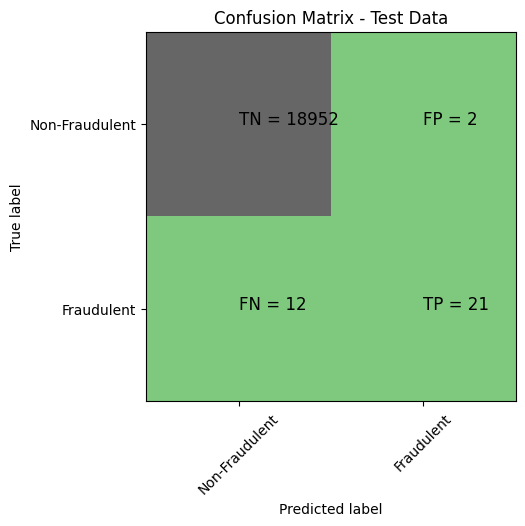


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       0.91      0.64      0.75        33

    accuracy                           1.00     18987
   macro avg       0.96      0.82      0.87     18987
weighted avg       1.00      1.00      1.00     18987

ROC-AUC: 0.9832880882263598
Best Threshold: 0.003109019216999345
ROC for the test dataset: 98.3%


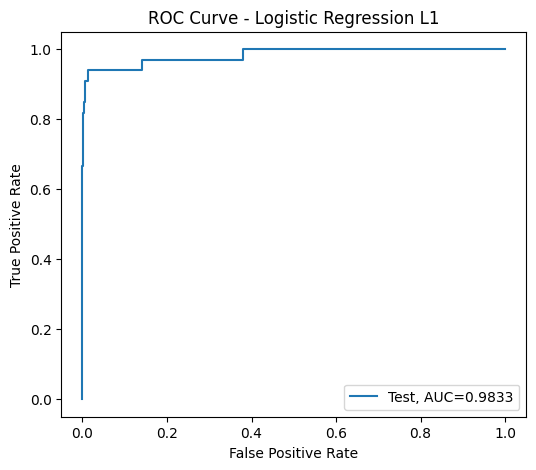


Logistic Regression - L2

Accuracy: 0.9988939800916417
Precision: 0.9285714285714286
Recall: 0.3939393939393939
F1 Score: 0.5531914893617021

Confusion Matrix


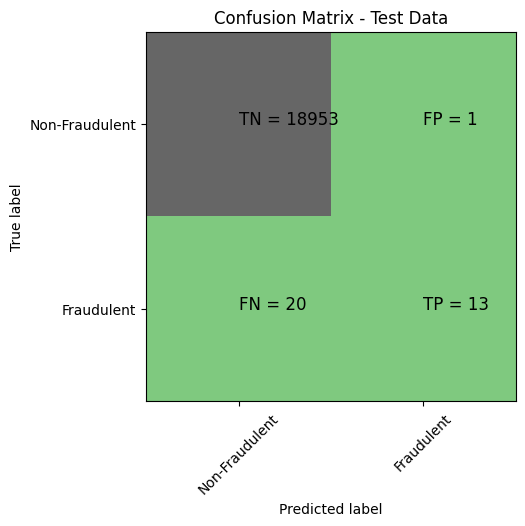


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       0.93      0.39      0.55        33

    accuracy                           1.00     18987
   macro avg       0.96      0.70      0.78     18987
weighted avg       1.00      1.00      1.00     18987

ROC-AUC: 0.9932196290220981
Best Threshold: 0.001487609965610695
ROC for the test dataset: 99.3%


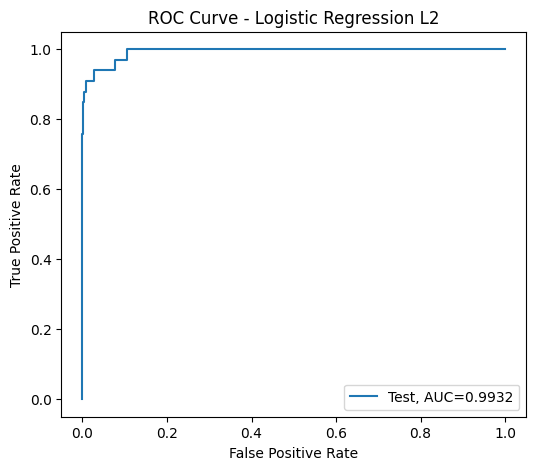

Time Taken by Model: --- 246.46542024612427 seconds --- 
------------------------------------------------------------
KNN Model
Model score
0.9991573181650603
Confusion Matrix


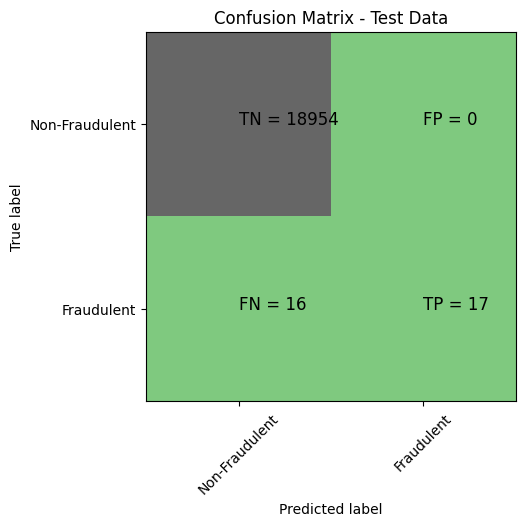

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       1.00      0.52      0.68        33

    accuracy                           1.00     18987
   macro avg       1.00      0.76      0.84     18987
weighted avg       1.00      1.00      1.00     18987

KNN roc_value: 0.8635116598079562
KNN threshold: 0.2
ROC for the test dataset 86.4%


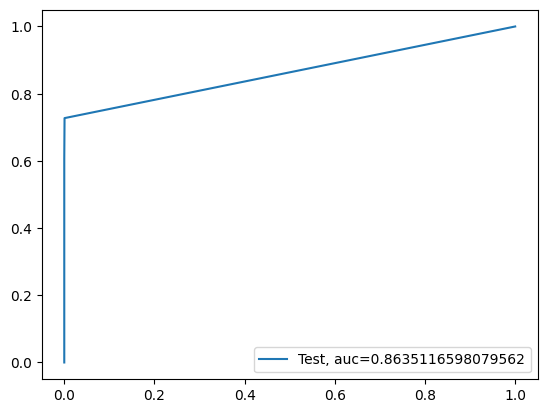

Time Taken by Model: --- 35.16247582435608 seconds --- 
------------------------------------------------------------
Decision Tree Models with 'gini' & 'entropy' criteria
gini score: 0.9990519829356929
Precision: 0.7272727272727273
Recall: 0.7272727272727273
F1 Score: 0.7272727272727273
Confusion Matrix


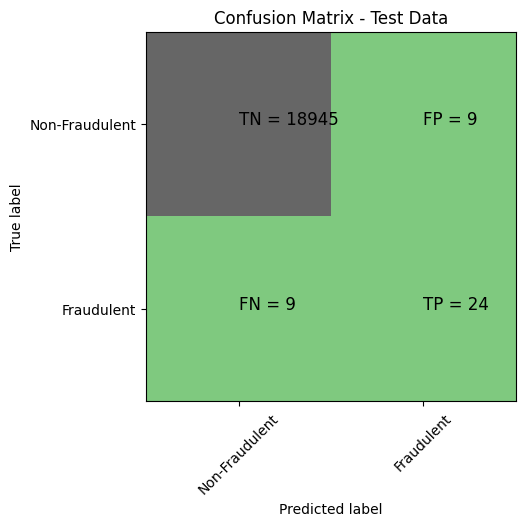

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       0.73      0.73      0.73        33

    accuracy                           1.00     18987
   macro avg       0.86      0.86      0.86     18987
weighted avg       1.00      1.00      1.00     18987

gini tree_roc_value: 0.86339894673228
Tree threshold: 1.0
ROC for the test dataset 86.3%


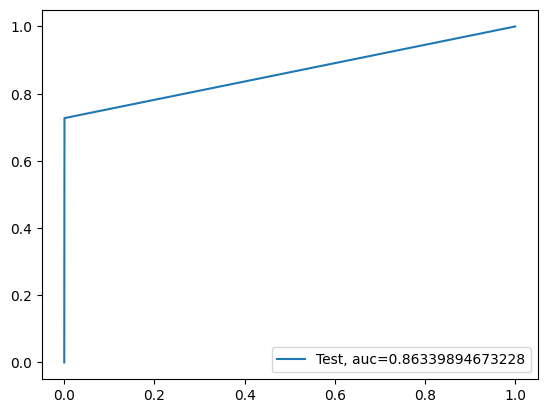

entropy score: 0.9992099857797441
Precision: 0.78125
Recall: 0.7575757575757576
F1 Score: 0.7692307692307693
Confusion Matrix


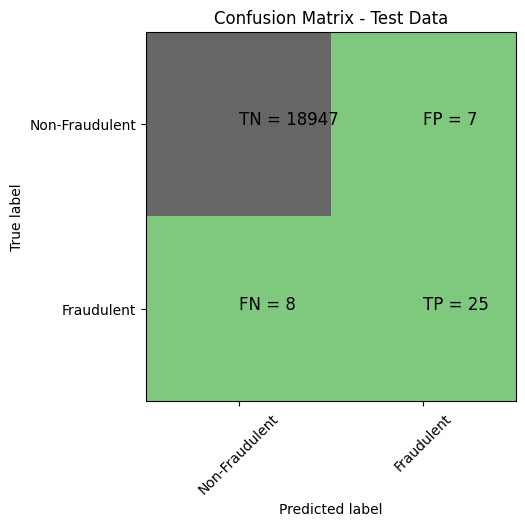

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       0.78      0.76      0.77        33

    accuracy                           1.00     18987
   macro avg       0.89      0.88      0.88     18987
weighted avg       1.00      1.00      1.00     18987

entropy tree_roc_value: 0.8786032211958138
Tree threshold: 1.0
ROC for the test dataset 87.9%


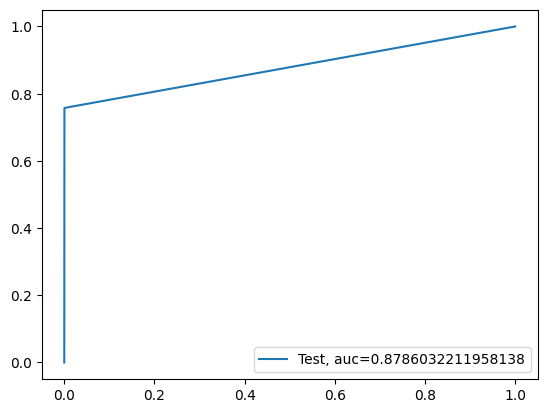

Time Taken by Model: --- 12.060815572738647 seconds --- 
------------------------------------------------------------
Random Forest Model
Model Accuracy: 0.9993153210091115
Precision: 0.9545454545454546
Recall: 0.6363636363636364
F1 Score: 0.7636363636363637
Confusion Matrix


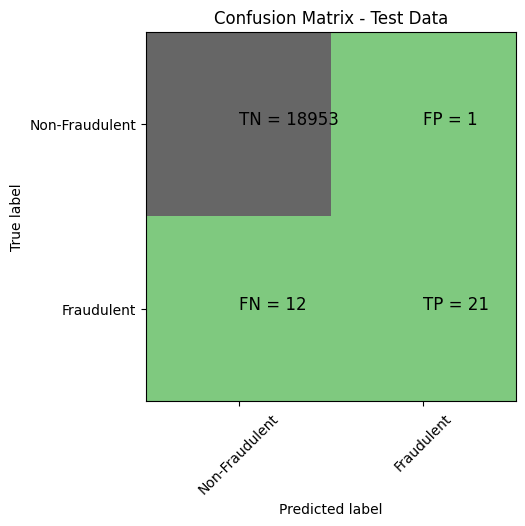

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       0.95      0.64      0.76        33

    accuracy                           1.00     18987
   macro avg       0.98      0.82      0.88     18987
weighted avg       1.00      1.00      1.00     18987

Random Forest roc_value: 0.9373595083471626
Random Forest threshold: 0.01
ROC for the test dataset 93.7%


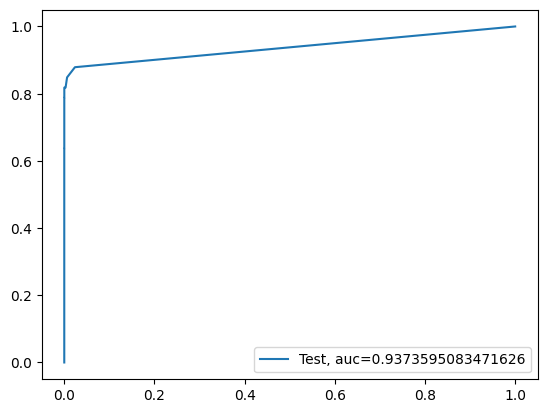

Time Taken by Model: --- 69.39935827255249 seconds --- 
------------------------------------------------------------
XGBoost Model
Model Accuracy: 0.9960499288987201
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Confusion Matrix


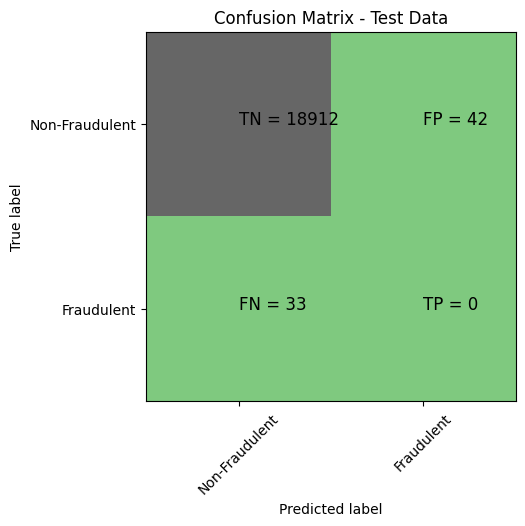

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       0.00      0.00      0.00        33

    accuracy                           1.00     18987
   macro avg       0.50      0.50      0.50     18987
weighted avg       1.00      1.00      1.00     18987

XGBoost roc_value: 0.4855871152167448
XGBoost threshold: inf
ROC for the test dataset 48.6%


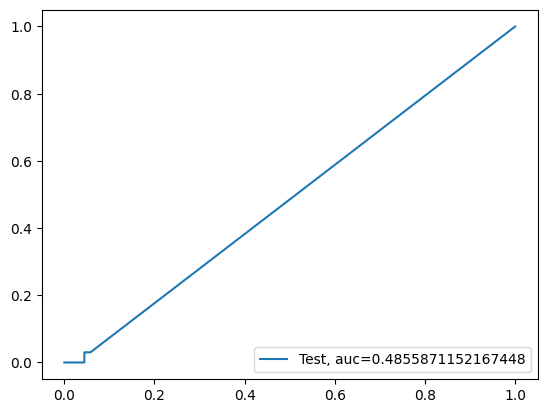

Time Taken by Model: --- 2.351780414581299 seconds --- 
------------------------------------------------------------
SVM Model with Sigmoid Kernel
accuracy_score : 0.9977352925685996
Precision: 0.1875
Recall: 0.09090909090909091
F1 Score: 0.12244897959183673
Confusion Matrix


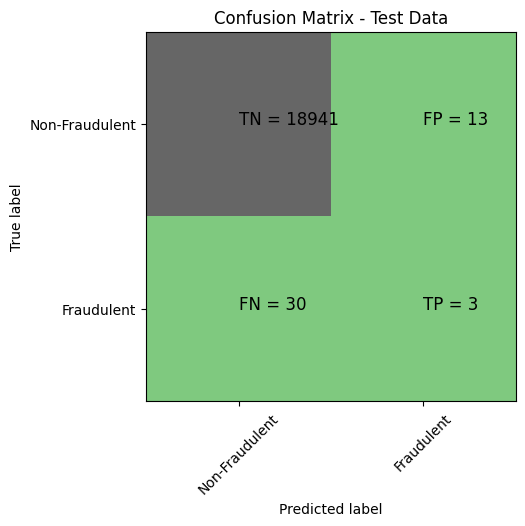

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       0.19      0.09      0.12        33

    accuracy                           1.00     18987
   macro avg       0.59      0.55      0.56     18987
weighted avg       1.00      1.00      1.00     18987

SVM roc_value: 0.7227274326039758
SVM threshold: 0.0017868752108727288
ROC for the test dataset 72.3%


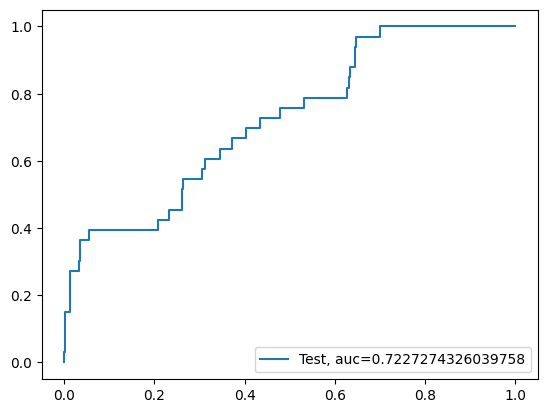

Time Taken by Model: --- 41.64695358276367 seconds --- 
------------------------------------------------------------


In [48]:
# Run Logistic Regression with L1 And L2 Regularisation
print("Logistic Regression with L1 And L2 Regularisation")
start_time = time.time()
df_Results = buildAndRunLogisticModels(
    df_Results,
    "StratifiedKFold Cross Validation",
    X_train_SKF_cv,
    y_train_SKF_cv,
    X_test_SKF_cv,
    y_test_SKF_cv
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 60)

# Run KNN Model
print("KNN Model")
start_time = time.time()
df_Results = buildAndRunKNNModels(
    df_Results,
    "StratifiedKFold Cross Validation",
    X_train_SKF_cv,
    y_train_SKF_cv,
    X_test_SKF_cv,
    y_test_SKF_cv
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 60)

# Run Decision Tree Models with 'gini' & 'entropy' criteria
print("Decision Tree Models with 'gini' & 'entropy' criteria")
start_time = time.time()
df_Results = buildAndRunTreeModels(
    df_Results,
    "StratifiedKFold Cross Validation",
    X_train_SKF_cv,
    y_train_SKF_cv,
    X_test_SKF_cv,
    y_test_SKF_cv
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 60)

# Run Random Forest Model
print("Random Forest Model")
start_time = time.time()
df_Results = buildAndRunRandomForestModels(
    df_Results,
    "StratifiedKFold Cross Validation",
    X_train_SKF_cv,
    y_train_SKF_cv,
    X_test_SKF_cv,
    y_test_SKF_cv
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 60)

# Run XGBoost Model
print("XGBoost Model")
start_time = time.time()
df_Results = buildAndRunXGBoostModels(
    df_Results,
    "StratifiedKFold Cross Validation",
    X_train_SKF_cv,
    y_train_SKF_cv,
    X_test_SKF_cv,
    y_test_SKF_cv
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 60)

# Run SVM Model with Sigmoid Kernel
print("SVM Model with Sigmoid Kernel")
start_time = time.time()
df_Results = buildAndRunSVMModels(
    df_Results,
    "StratifiedKFold Cross Validation",
    X_train_SKF_cv,
    y_train_SKF_cv,
    X_test_SKF_cv,
    y_test_SKF_cv
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 60)

In [49]:
# Checking the df_result dataframe which contains consolidated results of all the runs
df_Results

,Methodology,Model,Accuracy,roc_value,threshold,Precision,Recall,F1
0,RepeatedKFold Cross Validation,Logistic Regression with L1 Regularisation,0.999315,0.958522,0.004442,0.923077,0.685714,0.786885
1,RepeatedKFold Cross Validation,Logistic Regression with L2 Regularisation,0.998999,0.979524,0.001238,0.863636,0.542857,0.666667
2,RepeatedKFold Cross Validation,KNN,0.999052,0.871264,0.200000,0.904762,0.542857,0.678571
3,RepeatedKFold Cross Validation,Tree Model with gini criteria,0.999105,0.885477,1.000000,0.750000,0.771429,0.760563
4,RepeatedKFold Cross Validation,Tree Model with entropy criteria,0.999210,0.857011,1.000000,0.833333,0.714286,0.769231
5,RepeatedKFold Cross Validation,Random Forest,0.999315,0.912004,0.010000,0.866667,0.742857,0.800000
6,RepeatedKFold Cross Validation,XGBoost,0.995576,0.418296,0.999999,0.019608,0.028571,0.023256
7,RepeatedKFold Cross Validation,SVM,0.997472,0.668665,0.001576,0.066667,0.028571,0.040000
8,StratifiedKFold Cross Validation,Logistic Regression with L1 Regularisation,0.999263,0.983288,0.003109,0.913043,0.636364,0.750000
9,StratifiedKFold Cross Validation,Logistic Regression with L2 Regularisation,0.998894,0.993220,0.001488,0.928571,0.393939,0.553191


**Results for cross validatiion with StratifiedKFold:**

Looking at ROC value we have Logistic Regression with L2 Regulation has provided the best results for cross validation with StratifiedKFold technique

**Conclusion :**

As the results show Logistic Regression with L2 Regularisation for StratifiedKFold cross validation provided best results

**Proceed with the model which shows the best result**


* Apply the best hyperparameter on the model
*  Predict on the test dataset



In [50]:
# Logistic Regression
from sklearn import linear_model  # import the package
from sklearn.model_selection import KFold

num_C = list(np.power(10.0, np.arange(-10, 10)))
cv_num = KFold(n_splits=10, shuffle=True, random_state=42)

clf = linear_model.LogisticRegressionCV(
    Cs=num_C,
    penalty='l2',
    scoring='roc_auc',
    cv=cv_num,
    random_state=42,
    max_iter=10000,
    fit_intercept=True,
    solver='newton-cg',
    tol=1e-4
)

clf.fit(X_train_SKF_cv, y_train_SKF_cv)

print('Max auc_roc for l2:', clf.scores_[1].mean(axis=0).max())

print("Parameters for l2 regularisations")
print(clf.coef_)
print(clf.intercept_)
print(clf.scores_)

# Find predicted values
y_pred_l2 = clf.predict(X_test_SKF_cv)

# Find predicted probabilities
y_pred_probs_l2 = clf.predict_proba(X_test_SKF_cv)[:, 1]

# Accuracy of L2/L1 models
Accuracy_l2 = metrics.accuracy_score(
    y_pred=y_pred_l2,
    y_true=y_test_SKF_cv
)

print("Accuracy of Logistic model with l2 regularisation : {0}".format(Accuracy_l2))

from sklearn.metrics import roc_auc_score

l2_roc_value = roc_auc_score(y_test_SKF_cv, y_pred_probs_l2)

print("l2 roc_value: {0}".format(l2_roc_value))

fpr, tpr, thresholds = metrics.roc_curve(
    y_test_SKF_cv,
    y_pred_probs_l2
)

threshold = thresholds[np.argmax(tpr - fpr)]

print("l2 threshold: {0}".format(threshold))

Max auc_roc for l2: 0.9863766118087792
Parameters for l2 regularisations
[[-0.00273778  0.04932432 -0.09469343  0.14485796  0.03614825 -0.03708434
  -0.0600495  -0.04958972 -0.072733   -0.13743953  0.11080336 -0.15438756
  -0.02853798 -0.2481466  -0.00369624 -0.09308842 -0.11232712 -0.02959457
   0.00148078  0.02067761  0.01594985  0.01111249  0.0006526  -0.00906867
  -0.0007716   0.00316917  0.00686517  0.00783608  0.00037573  0.00341965]]
[-7.19463818]
{np.int64(1): array([[0.47946424, 0.47946424, 0.48615434, 0.6358445 , 0.89950953,
        0.98633496, 0.998423  , 0.99968738, 0.99968738, 0.99945118,
        0.99945118, 0.99945118, 0.99945118, 0.99945118, 0.99945118,
        0.99945118, 0.99945118, 0.99945118, 0.99945118, 0.99945118],
       [0.57505937, 0.57505937, 0.58264613, 0.68858029, 0.90138046,
        0.97869937, 0.99775696, 0.99991754, 0.99993403, 0.99991754,
        0.99991754, 0.99991754, 0.99991754, 0.99991754, 0.99991754,
        0.99991754, 0.99991754, 0.99991754, 0.9999

In [51]:
# Checking for the coefficient values
clf.coef_

array([[-0.00273778,  0.04932432, -0.09469343,  0.14485796,  0.03614825,
        -0.03708434, -0.0600495 , -0.04958972, -0.072733  , -0.13743953,
         0.11080336, -0.15438756, -0.02853798, -0.2481466 , -0.00369624,
        -0.09308842, -0.11232712, -0.02959457,  0.00148078,  0.02067761,
         0.01594985,  0.01111249,  0.0006526 , -0.00906867, -0.0007716 ,
         0.00316917,  0.00686517,  0.00783608,  0.00037573,  0.00341965]])

In [52]:
# Creating a dataframe with the coefficient values
coefficients = pd.concat(
    [pd.DataFrame(X.columns), pd.DataFrame(np.transpose(clf.coef_))],
    axis=1
)

coefficients.columns = ['Feature', 'Importance Coefficient']

In [53]:
coefficients

,Feature,Importance Coefficient
0,V1,-0.002738
1,V2,0.049324
2,V3,-0.094693
3,V4,0.144858
4,V5,0.036148
5,V6,-0.037084
6,V7,-0.060049
7,V8,-0.049590
8,V9,-0.072733
9,V10,-0.137440


**Print the important features of the best model to understand the dataset**



* This will not give much explanation on the already transformed dataset
* But it will help us in understanding if the dataset is not PCA transformed


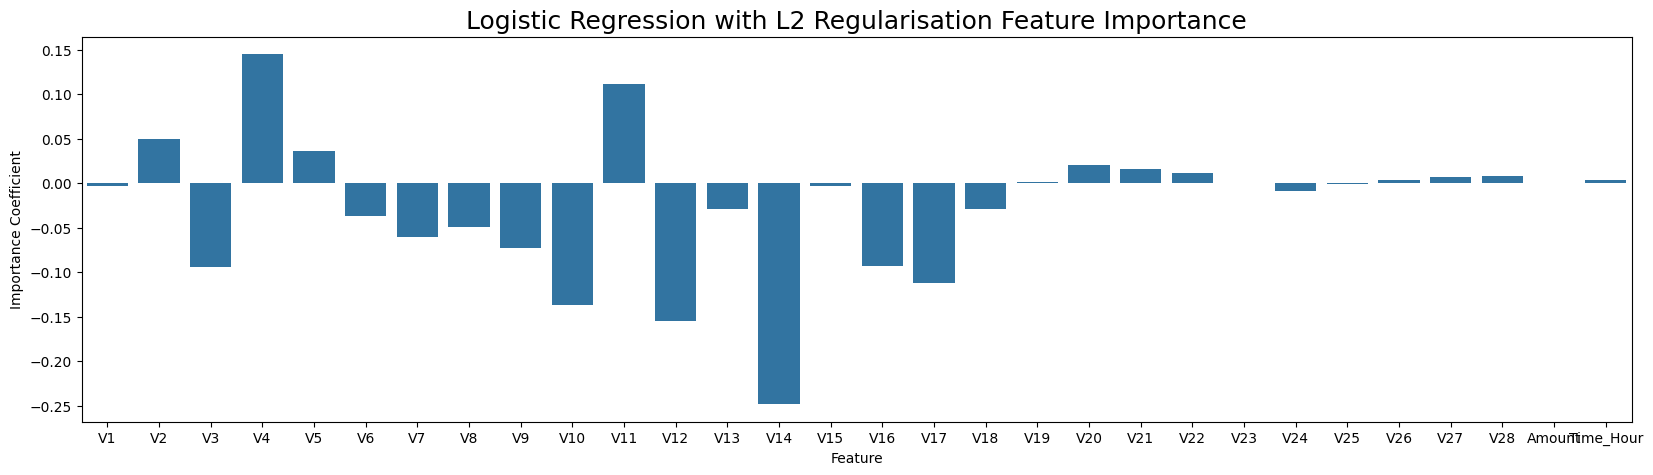

In [54]:
# Plotting the coefficient values
plt.figure(figsize=(20, 5))
sns.barplot(x='Feature', y='Importance Coefficient', data=coefficients)
plt.title("Logistic Regression with L2 Regularisation Feature Importance", fontsize=18)

plt.show()

Hence it implies that V2, v2,V11 has + ve importance whereas V10, V12, V14 seems to have -ve impact on the predictaions

Model building with balancing Classes

Perform class balancing with :



* Random Oversampling
* ADASYN
* SMOTE


Oversampling with RandomOverSampler with StratifiedKFold Cross Validation

* We will use Random Oversampling method to handle the class imbalance

In [55]:
# Creating the dataset with RandomOverSampler and StratifiedKFold
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import RandomOverSampler

skf = StratifiedKFold(n_splits=5, random_state=None)

for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
  X_train = X.loc[train_index]
  y_train = y.loc[train_index]
  X_test = X.loc[test_index]
  y_test = y.loc[test_index]

  ROS = RandomOverSampler(sampling_strategy=0.5)
  X_over, y_over = ROS.fit_resample(X_train, y_train)

  X_over = pd.DataFrame(data=X_over, columns=cols)

Logistic Regression with L1 And L2 Regularisation
Training L1 Logistic Regression...
Training L2 Logistic Regression...

Best C for L1: [1000.]
Best C for L2: [1.]

Logistic Regression - L1

Accuracy: 0.9830936956865224
Precision: 0.08857142857142856
Recall: 0.9393939393939394
F1 Score: 0.1618798955613577

Confusion Matrix


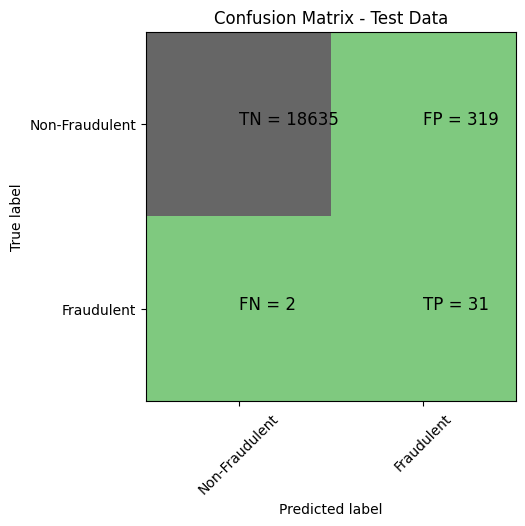


Classification Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     18954
           1       0.09      0.94      0.16        33

    accuracy                           0.98     18987
   macro avg       0.54      0.96      0.58     18987
weighted avg       1.00      0.98      0.99     18987

ROC-AUC: 0.9752534845127437
Best Threshold: 0.37106915712605243
ROC for the test dataset: 97.5%


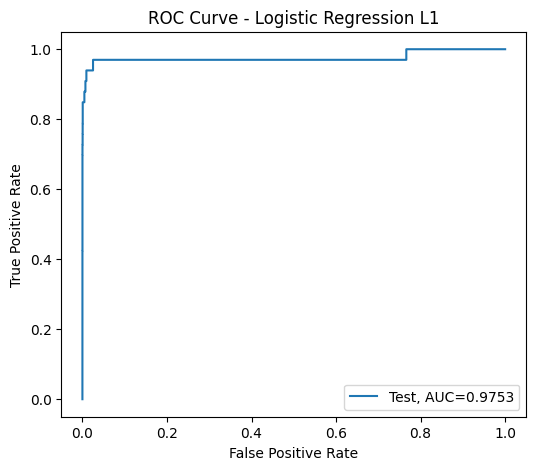


Logistic Regression - L2

Accuracy: 0.9831463633012061
Precision: 0.08882521489971347
Recall: 0.9393939393939394
F1 Score: 0.16230366492146597

Confusion Matrix


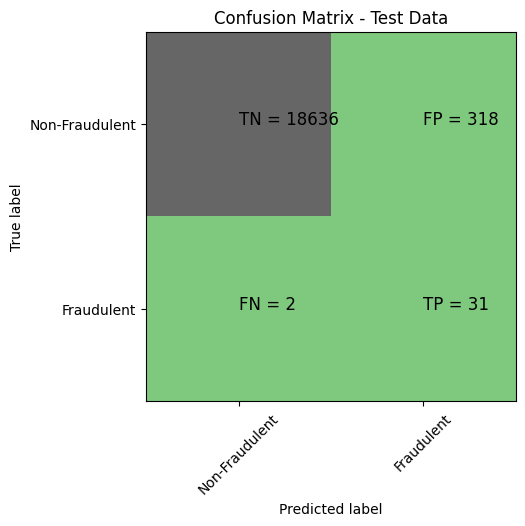


Classification Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     18954
           1       0.09      0.94      0.16        33

    accuracy                           0.98     18987
   macro avg       0.54      0.96      0.58     18987
weighted avg       1.00      0.98      0.99     18987

ROC-AUC: 0.9751831387633857
Best Threshold: 0.37156011159107927
ROC for the test dataset: 97.5%


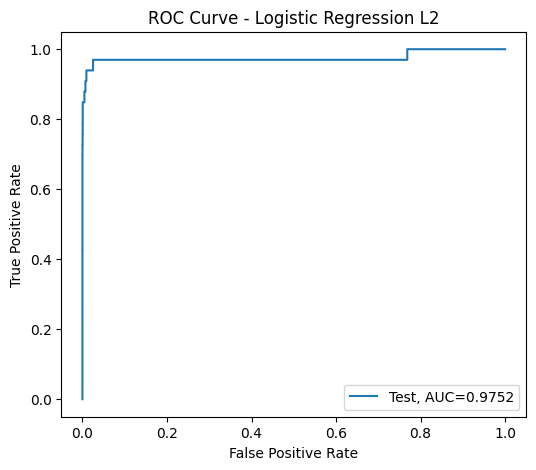

Time Taken by Model: --- 892.522458076477 seconds --- 
------------------------------------------------------------
KNN Model
Model score
0.9990519829356929
Confusion Matrix


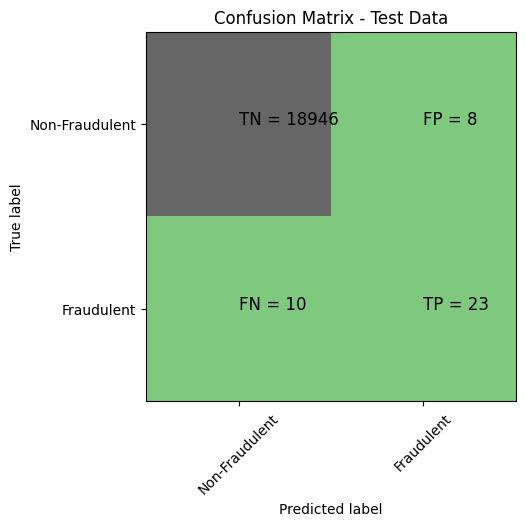

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       0.74      0.70      0.72        33

    accuracy                           1.00     18987
   macro avg       0.87      0.85      0.86     18987
weighted avg       1.00      1.00      1.00     18987

KNN roc_value: 0.8634477091267215
KNN threshold: 0.4
ROC for the test dataset 86.3%


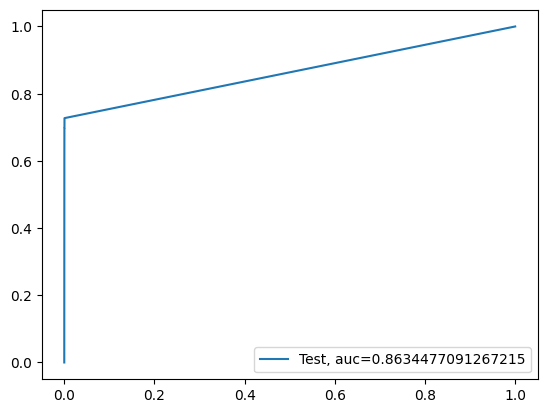

Time Taken by Model: --- 52.73073387145996 seconds --- 
------------------------------------------------------------
Decision Tree Models with 'gini' & 'entropy' criteria
gini score: 0.9987886448622741
Precision: 0.6785714285714286
Recall: 0.5757575757575758
F1 Score: 0.6229508196721312
Confusion Matrix


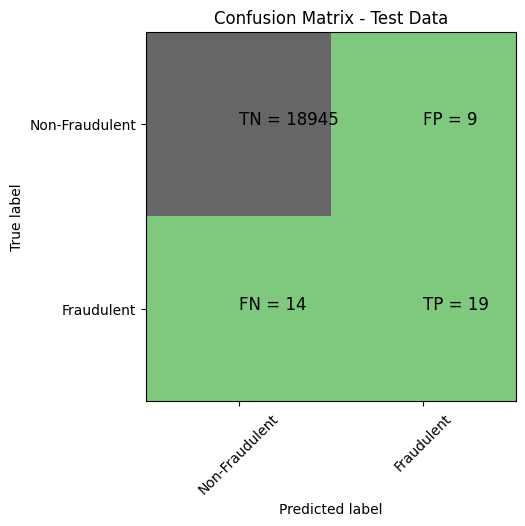

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       0.68      0.58      0.62        33

    accuracy                           1.00     18987
   macro avg       0.84      0.79      0.81     18987
weighted avg       1.00      1.00      1.00     18987

gini tree_roc_value: 0.7876413709747043
Tree threshold: 1.0
ROC for the test dataset 78.8%


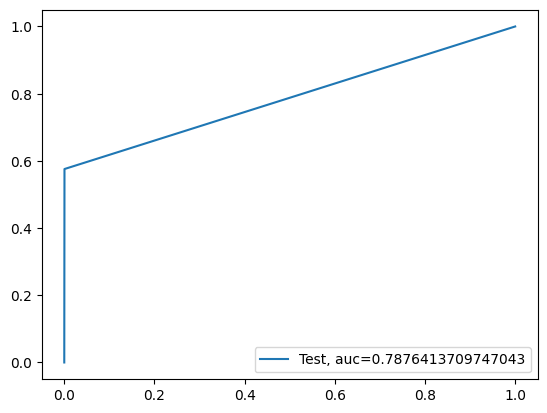

entropy score: 0.9988939800916417
Precision: 0.75
Recall: 0.5454545454545454
F1 Score: 0.631578947368421
Confusion Matrix


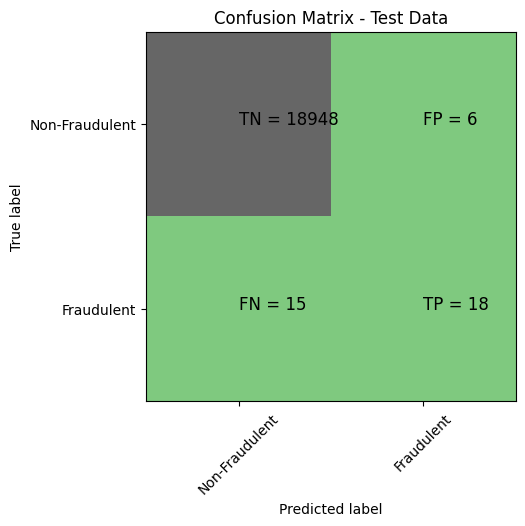

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       0.75      0.55      0.63        33

    accuracy                           1.00     18987
   macro avg       0.87      0.77      0.82     18987
weighted avg       1.00      1.00      1.00     18987

entropy tree_roc_value: 0.772568994791217
Tree threshold: 1.0
ROC for the test dataset 77.3%


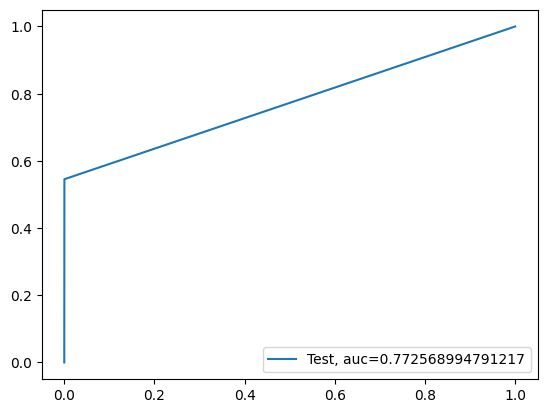

Time Taken by Model: --- 8.385924577713013 seconds --- 
------------------------------------------------------------
Random Forest Model
Model Accuracy: 0.9994733238531627
Precision: 1.0
Recall: 0.696969696969697
F1 Score: 0.8214285714285714
Confusion Matrix


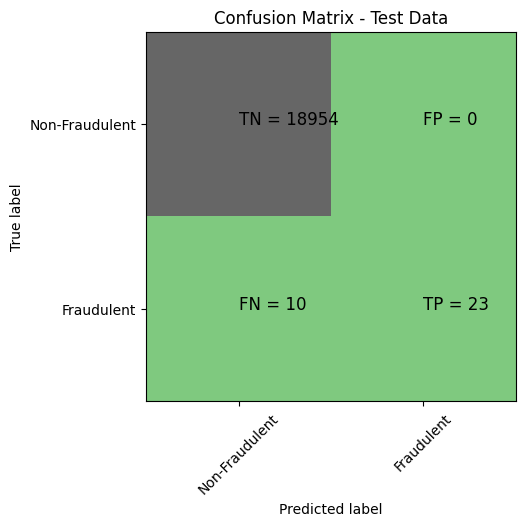

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       1.00      0.70      0.82        33

    accuracy                           1.00     18987
   macro avg       1.00      0.85      0.91     18987
weighted avg       1.00      1.00      1.00     18987

Random Forest roc_value: 0.9674515014021188
Random Forest threshold: 0.01
ROC for the test dataset 96.7%


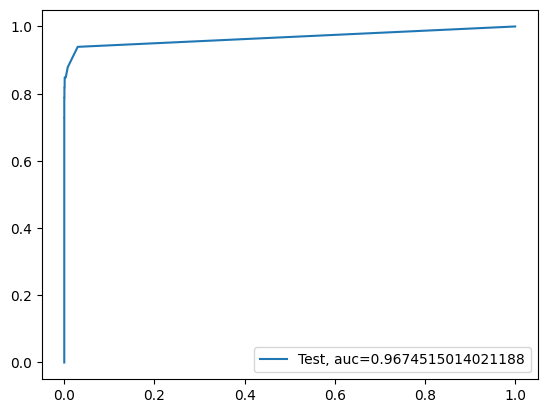

Time Taken by Model: --- 52.60897946357727 seconds --- 
------------------------------------------------------------
XGBoost Model
Model Accuracy: 0.9995259914678464
Precision: 0.9615384615384616
Recall: 0.7575757575757576
F1 Score: 0.847457627118644
Confusion Matrix


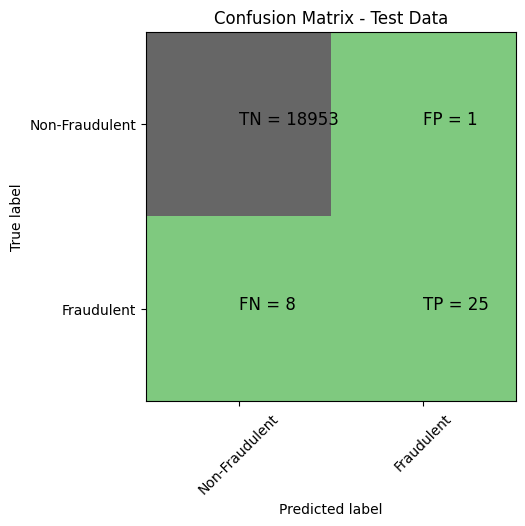

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       0.96      0.76      0.85        33

    accuracy                           1.00     18987
   macro avg       0.98      0.88      0.92     18987
weighted avg       1.00      1.00      1.00     18987

XGBoost roc_value: 0.9733021893515721
XGBoost threshold: 3.786107845371589e-05
ROC for the test dataset 97.3%


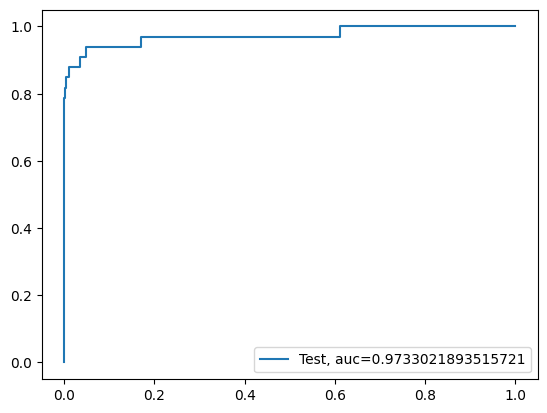

Time Taken by Model: --- 2.3941338062286377 seconds --- 
------------------------------------------------------------


In [56]:
Data_Imbalance_Handiling = "Random Oversampling with StratifiedKFold CV"

# Run Logistic Regression with L1 And L2 Regularisation
print("Logistic Regression with L1 And L2 Regularisation")
start_time = time.time()
df_Results = buildAndRunLogisticModels(
    df_Results, Data_Imbalance_Handiling, X_over, y_over, X_test, y_test
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 60)

# Run KNN Model
print("KNN Model")
start_time = time.time()
df_Results = buildAndRunKNNModels(
    df_Results, Data_Imbalance_Handiling, X_over, y_over, X_test, y_test
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 60)

# Run Decision Tree Models with 'gini' & 'entropy' criteria
print("Decision Tree Models with 'gini' & 'entropy' criteria")
start_time = time.time()
df_Results = buildAndRunTreeModels(
    df_Results, Data_Imbalance_Handiling, X_over, y_over, X_test, y_test
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 60)

# Run Random Forest Model
print("Random Forest Model")
start_time = time.time()
df_Results = buildAndRunRandomForestModels(
    df_Results, Data_Imbalance_Handiling, X_over, y_over, X_test, y_test
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 60)

# Run XGBoost Model
print("XGBoost Model")
start_time = time.time()
df_Results = buildAndRunXGBoostModels(
    df_Results, Data_Imbalance_Handiling, X_over, y_over, X_test, y_test
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 60)

In [57]:
# Checking the df_result dataframe which contains consolidated results of all the runs
df_Results

,Methodology,Model,Accuracy,roc_value,threshold,Precision,Recall,F1
0,RepeatedKFold Cross Validation,Logistic Regression with L1 Regularisation,0.999315,0.958522,0.004442,0.923077,0.685714,0.786885
1,RepeatedKFold Cross Validation,Logistic Regression with L2 Regularisation,0.998999,0.979524,0.001238,0.863636,0.542857,0.666667
2,RepeatedKFold Cross Validation,KNN,0.999052,0.871264,0.200000,0.904762,0.542857,0.678571
3,RepeatedKFold Cross Validation,Tree Model with gini criteria,0.999105,0.885477,1.000000,0.750000,0.771429,0.760563
4,RepeatedKFold Cross Validation,Tree Model with entropy criteria,0.999210,0.857011,1.000000,0.833333,0.714286,0.769231
5,RepeatedKFold Cross Validation,Random Forest,0.999315,0.912004,0.010000,0.866667,0.742857,0.800000
6,RepeatedKFold Cross Validation,XGBoost,0.995576,0.418296,0.999999,0.019608,0.028571,0.023256
7,RepeatedKFold Cross Validation,SVM,0.997472,0.668665,0.001576,0.066667,0.028571,0.040000
8,StratifiedKFold Cross Validation,Logistic Regression with L1 Regularisation,0.999263,0.983288,0.003109,0.913043,0.636364,0.750000
9,StratifiedKFold Cross Validation,Logistic Regression with L2 Regularisation,0.998894,0.993220,0.001488,0.928571,0.393939,0.553191


**Results for Random Oversampling with StratifiedKFold technique:**


Looking at the Accuracy and ROC value we have XGBoost which has provided best results for Random Oversampling and StratifiedKFold technique

Oversampling with SMOTE Oversampling with StratifiedKFold Cross Validation

* We will use SMOTE Oversampling method to handle the class imbalance

In [58]:
# Creating dataframe with SMOTE and StratifiedKFold
from sklearn.model_selection import StratifiedKFold
from imblearn import over_sampling

skf = StratifiedKFold(n_splits=5, random_state=None)

for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
  X_train = X.loc[train_index]
  y_train = y.loc[train_index]
  X_test = X.loc[test_index]
  y_test = y.loc[test_index]

  SMOTE = over_sampling.SMOTE(random_state=0)
  X_train_Smote, y_train_Smote = SMOTE.fit_resample(X_train, y_train)

  X_train_Smote = pd.DataFrame(data=X_train_Smote, columns=cols)

Logistic Regression with L1 And L2 Regularisation
Training L1 Logistic Regression...
Training L2 Logistic Regression...

Best C for L1: [1000.]
Best C for L2: [1.]

Logistic Regression - L1

Accuracy: 0.9801443092642335
Precision: 0.07635467980295567
Recall: 0.9393939393939394
F1 Score: 0.14123006833712984

Confusion Matrix


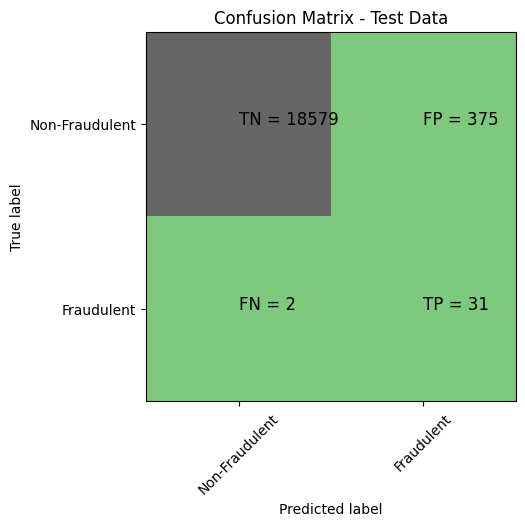


Classification Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     18954
           1       0.08      0.94      0.14        33

    accuracy                           0.98     18987
   macro avg       0.54      0.96      0.57     18987
weighted avg       1.00      0.98      0.99     18987

ROC-AUC: 0.9780673144870676
Best Threshold: 0.7959668253039323
ROC for the test dataset: 97.8%


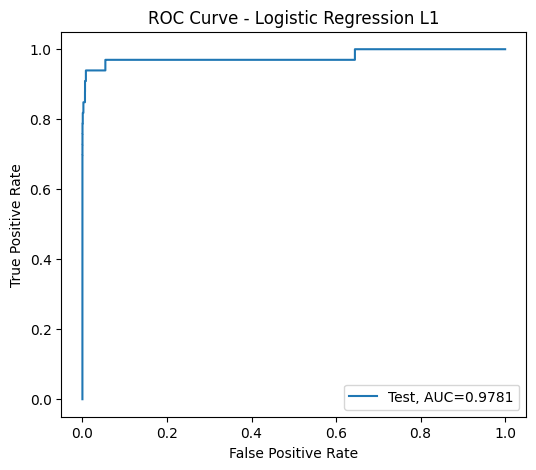


Logistic Regression - L2

Accuracy: 0.980038974034866
Precision: 0.07598039215686274
Recall: 0.9393939393939394
F1 Score: 0.14058956916099774

Confusion Matrix


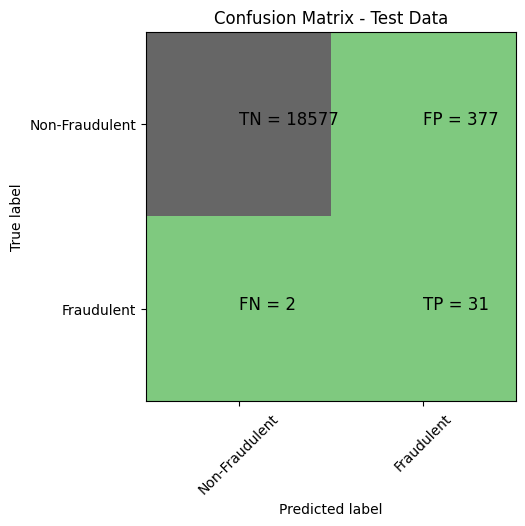


Classification Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     18954
           1       0.08      0.94      0.14        33

    accuracy                           0.98     18987
   macro avg       0.54      0.96      0.57     18987
weighted avg       1.00      0.98      0.99     18987

ROC-AUC: 0.978086499691438
Best Threshold: 0.7971620660537693
ROC for the test dataset: 97.8%


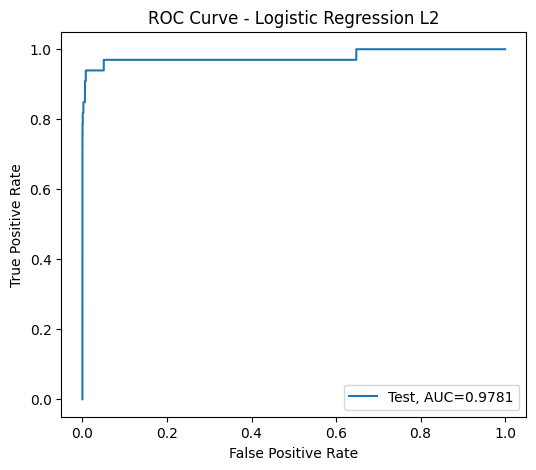

Time Taken by Model: --- 1324.3042740821838 seconds --- 
--------------------------------------------------------------------------------
KNN Model
Model score
0.9953652499078317
Confusion Matrix


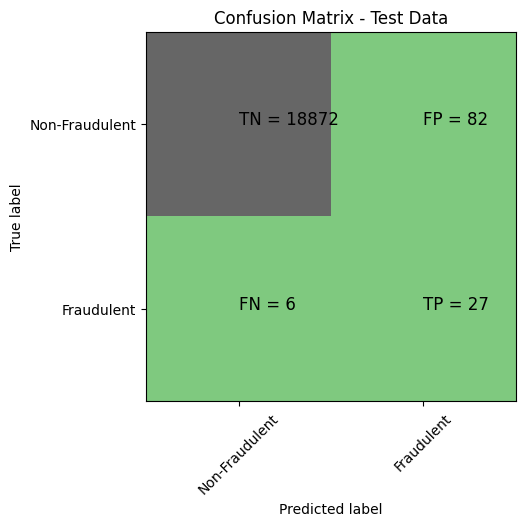

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       0.25      0.82      0.38        33

    accuracy                           1.00     18987
   macro avg       0.62      0.91      0.69     18987
weighted avg       1.00      1.00      1.00     18987

KNN roc_value: 0.907783117659661
KNN threshold: 0.6
ROC for the test dataset 90.8%


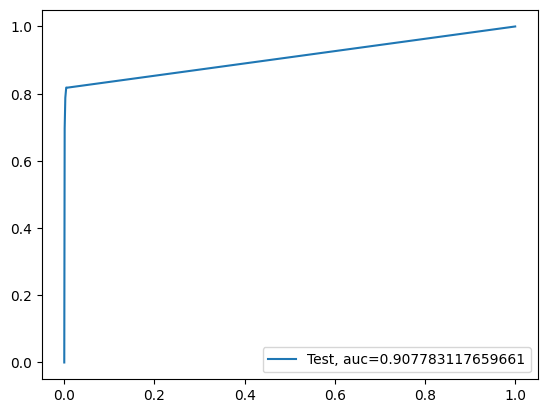

Time Taken by Model: --- 71.12947297096252 seconds --- 
--------------------------------------------------------------------------------
Decision Tree Models with 'gini' & 'entropy' criteria
gini score: 0.9982093011007531
Precision: 0.4878048780487805
Recall: 0.6060606060606061
F1 Score: 0.5405405405405406
Confusion Matrix


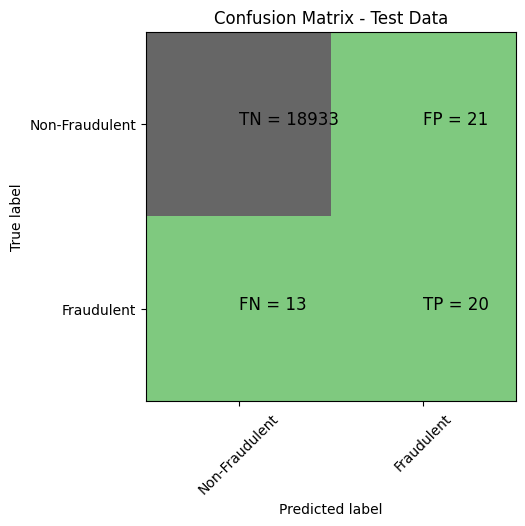

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       0.49      0.61      0.54        33

    accuracy                           1.00     18987
   macro avg       0.74      0.80      0.77     18987
weighted avg       1.00      1.00      1.00     18987

gini tree_roc_value: 0.8024763302541079
Tree threshold: 1.0
ROC for the test dataset 80.2%


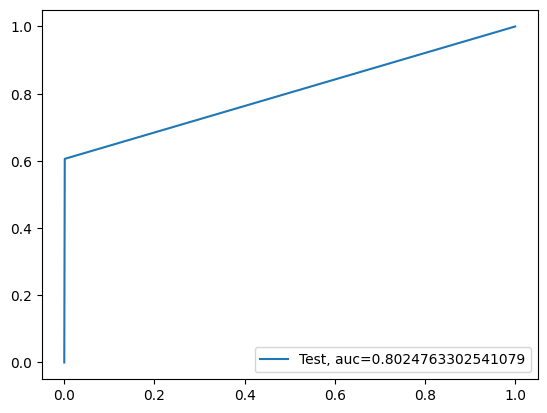

entropy score: 0.9983673039448043
Precision: 0.5217391304347826
Recall: 0.7272727272727273
F1 Score: 0.6075949367088608
Confusion Matrix


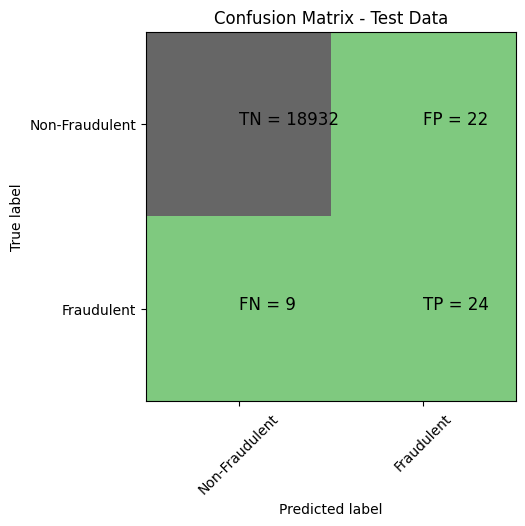

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       0.52      0.73      0.61        33

    accuracy                           1.00     18987
   macro avg       0.76      0.86      0.80     18987
weighted avg       1.00      1.00      1.00     18987

entropy tree_roc_value: 0.8630560112041594
Tree threshold: 1.0
ROC for the test dataset 86.3%


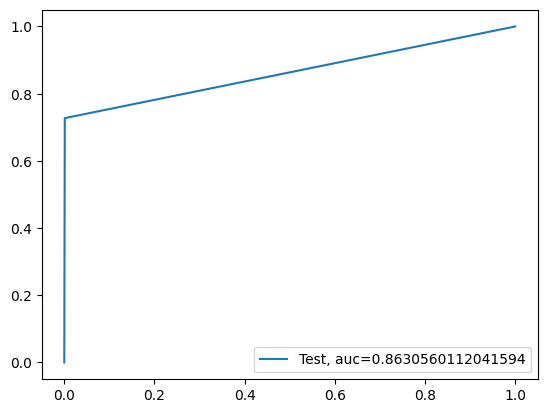

Time Taken by Model: --- 28.45816659927368 seconds --- 
--------------------------------------------------------------------------------
Random Forest Model
Model Accuracy: 0.9995259914678464
Precision: 0.9615384615384616
Recall: 0.7575757575757576
F1 Score: 0.847457627118644
Confusion Matrix


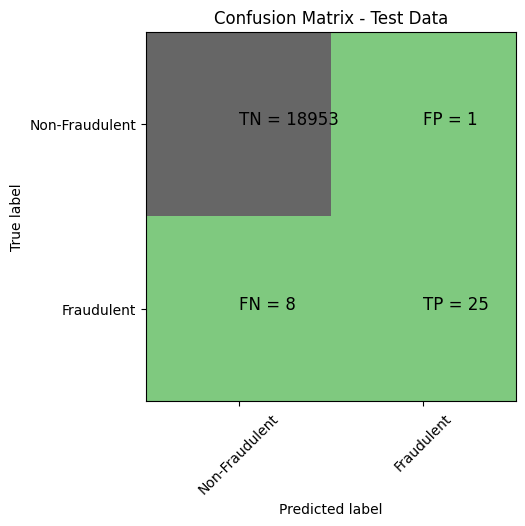

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       0.96      0.76      0.85        33

    accuracy                           1.00     18987
   macro avg       0.98      0.88      0.92     18987
weighted avg       1.00      1.00      1.00     18987

Random Forest roc_value: 0.9790145839528556
Random Forest threshold: 0.03
ROC for the test dataset 97.9%


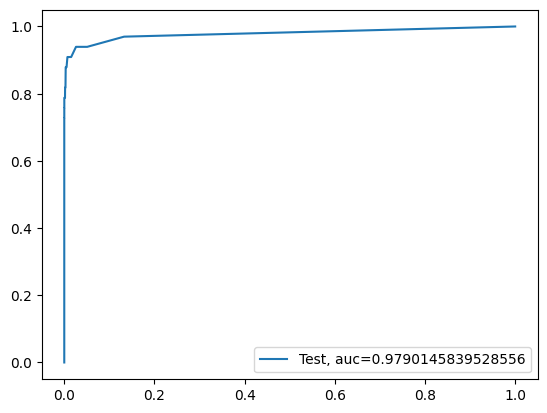

Time Taken by Model: --- 144.7793071269989 seconds --- 
--------------------------------------------------------------------------------
XGBoost Model
Model Accuracy: 0.9995259914678464
Precision: 0.9285714285714286
Recall: 0.7878787878787878
F1 Score: 0.8524590163934426
Confusion Matrix


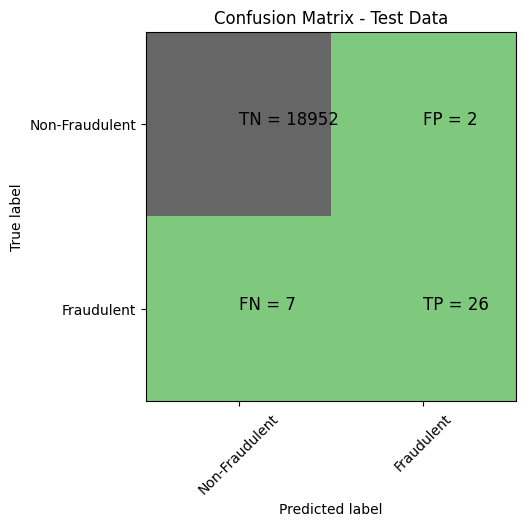

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       0.93      0.79      0.85        33

    accuracy                           1.00     18987
   macro avg       0.96      0.89      0.93     18987
weighted avg       1.00      1.00      1.00     18987

XGBoost roc_value: 0.9820570376125931
XGBoost threshold: 0.000832211459055543
ROC for the test dataset 98.2%


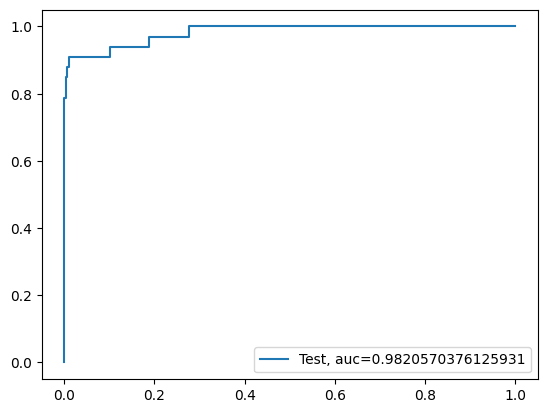

Time Taken by Model: --- 4.107344150543213 seconds --- 
--------------------------------------------------------------------------------


In [59]:
Data_Imbalance_Handiling = "SMOTE Oversampling with StratifiedKFold CV"

# Run Logistic Regression with L1 And L2 Regularisation
print("Logistic Regression with L1 And L2 Regularisation")
start_time = time.time()
df_Results = buildAndRunLogisticModels(
    df_Results, Data_Imbalance_Handiling, X_train_Smote, y_train_Smote, X_test, y_test
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 80)

# Run KNN Model
print("KNN Model")
start_time = time.time()
df_Results = buildAndRunKNNModels(
    df_Results, Data_Imbalance_Handiling, X_train_Smote, y_train_Smote, X_test, y_test
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 80)

# Run Decision Tree Models with 'gini' & 'entropy' criteria
print("Decision Tree Models with 'gini' & 'entropy' criteria")
start_time = time.time()
df_Results = buildAndRunTreeModels(
    df_Results, Data_Imbalance_Handiling, X_train_Smote, y_train_Smote, X_test, y_test
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 80)

# Run Random Forest Model
print("Random Forest Model")
start_time = time.time()
df_Results = buildAndRunRandomForestModels(
    df_Results, Data_Imbalance_Handiling, X_train_Smote, y_train_Smote, X_test, y_test
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 80)

# Run XGBoost Model
print("XGBoost Model")
start_time = time.time()
df_Results = buildAndRunXGBoostModels(
    df_Results, Data_Imbalance_Handiling, X_train_Smote, y_train_Smote, X_test, y_test
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 80)

In [60]:
# Checking the df_result dataframe which contains consolidated results of all the runs
df_Results

,Methodology,Model,Accuracy,roc_value,threshold,Precision,Recall,F1
0,RepeatedKFold Cross Validation,Logistic Regression with L1 Regularisation,0.999315,0.958522,0.004442,0.923077,0.685714,0.786885
1,RepeatedKFold Cross Validation,Logistic Regression with L2 Regularisation,0.998999,0.979524,0.001238,0.863636,0.542857,0.666667
2,RepeatedKFold Cross Validation,KNN,0.999052,0.871264,0.200000,0.904762,0.542857,0.678571
3,RepeatedKFold Cross Validation,Tree Model with gini criteria,0.999105,0.885477,1.000000,0.750000,0.771429,0.760563
4,RepeatedKFold Cross Validation,Tree Model with entropy criteria,0.999210,0.857011,1.000000,0.833333,0.714286,0.769231
5,RepeatedKFold Cross Validation,Random Forest,0.999315,0.912004,0.010000,0.866667,0.742857,0.800000
6,RepeatedKFold Cross Validation,XGBoost,0.995576,0.418296,0.999999,0.019608,0.028571,0.023256
7,RepeatedKFold Cross Validation,SVM,0.997472,0.668665,0.001576,0.066667,0.028571,0.040000
8,StratifiedKFold Cross Validation,Logistic Regression with L1 Regularisation,0.999263,0.983288,0.003109,0.913043,0.636364,0.750000
9,StratifiedKFold Cross Validation,Logistic Regression with L2 Regularisation,0.998894,0.993220,0.001488,0.928571,0.393939,0.553191


Results for SMOTE Oversampling with StratifiedKFold:

Looking at Accuracy and ROC value we have XGBoost which has provided best results for SMOTE Oversampling with StratifiedKFold technique

Oversampling with ADASYN with StratifiedKFold Cross Validation

* We will use ADASYN Oversampling method to handle the class imbalance

In [61]:
# Creating dataframe with ADASYN and StratifiedKFold
from sklearn.model_selection import StratifiedKFold
from imblearn import over_sampling

skf = StratifiedKFold(n_splits=5, random_state=None)

for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
  X_train = X.loc[train_index]
  y_train = y.loc[train_index]
  X_test = X.loc[test_index]
  y_test = y.loc[test_index]

  ADASYN = over_sampling.ADASYN(random_state=0)
  X_train_ADASYN, y_train_ADASYN = ADASYN.fit_resample(X_train, y_train)

  X_train_ADASYN = pd.DataFrame(data=X_train_ADASYN, columns=cols)

Logistic Regression with L1 And L2 Regularisation
Training L1 Logistic Regression...
Training L2 Logistic Regression...

Best C for L1: [1000.]
Best C for L2: [1.]

Logistic Regression - L1

Accuracy: 0.9645020277031653
Precision: 0.04539007092198582
Recall: 0.9696969696969697
F1 Score: 0.08672086720867209

Confusion Matrix


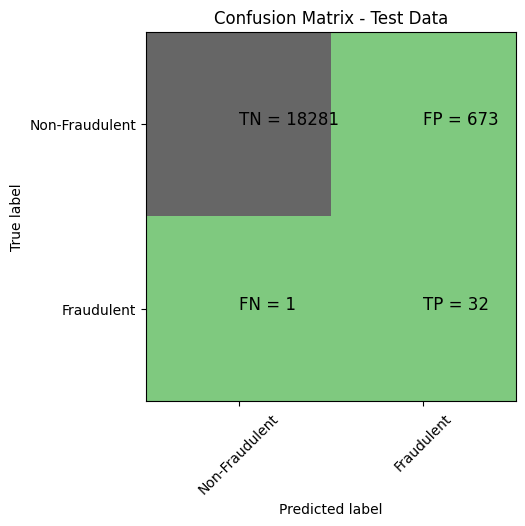


Classification Report
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     18954
           1       0.05      0.97      0.09        33

    accuracy                           0.96     18987
   macro avg       0.52      0.97      0.53     18987
weighted avg       1.00      0.96      0.98     18987

ROC-AUC: 0.9774286070582368
Best Threshold: 0.5498428461907883
ROC for the test dataset: 97.7%


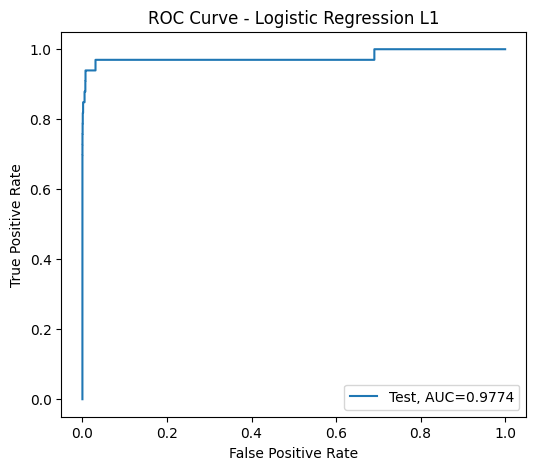


Logistic Regression - L2

Accuracy: 0.9641333544003792
Precision: 0.0449438202247191
Recall: 0.9696969696969697
F1 Score: 0.08590604026845637

Confusion Matrix


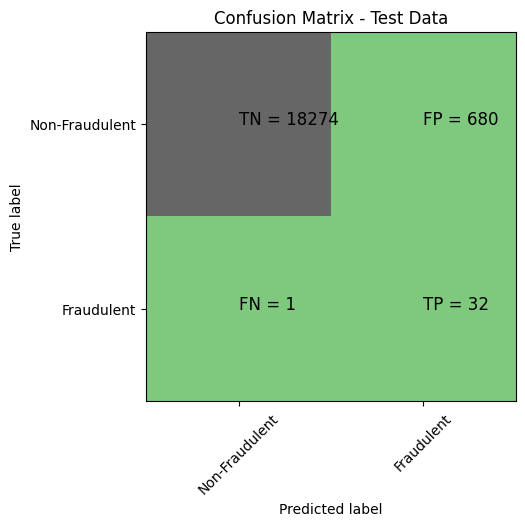


Classification Report
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     18954
           1       0.04      0.97      0.09        33

    accuracy                           0.96     18987
   macro avg       0.52      0.97      0.53     18987
weighted avg       1.00      0.96      0.98     18987

ROC-AUC: 0.9773582613088786
Best Threshold: 0.5801944390950786
ROC for the test dataset: 97.7%


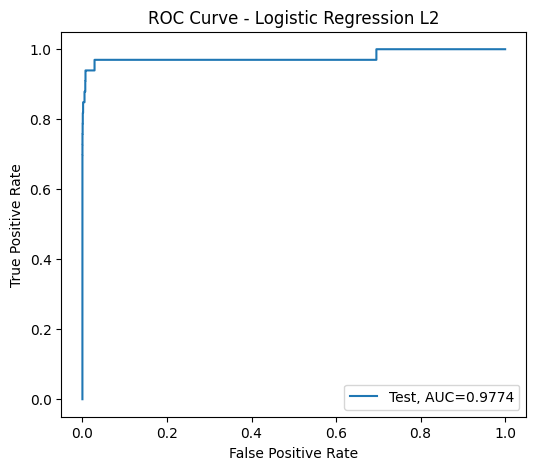

Time Taken by Model: --- 2009.1388852596283 seconds --- 
--------------------------------------------------------------------------------
KNN Model
Model score
0.9945752356875757
Confusion Matrix


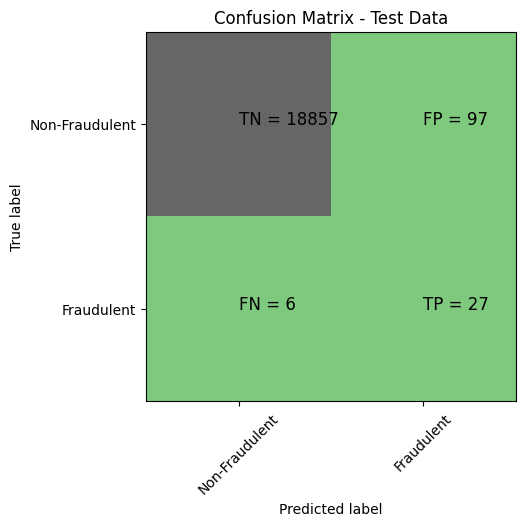

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     18954
           1       0.22      0.82      0.34        33

    accuracy                           0.99     18987
   macro avg       0.61      0.91      0.67     18987
weighted avg       1.00      0.99      1.00     18987

KNN roc_value: 0.907437783980994
KNN threshold: 0.6
ROC for the test dataset 90.7%


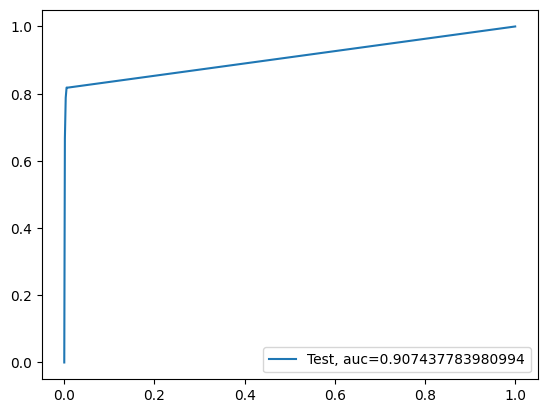

Time Taken by Model: --- 70.61228847503662 seconds --- 
--------------------------------------------------------------------------------
Decision Tree Models with 'gini' & 'entropy' criteria
gini score: 0.9983146363301206
Precision: 0.5102040816326531
Recall: 0.7575757575757576
F1 Score: 0.6097560975609756
Confusion Matrix


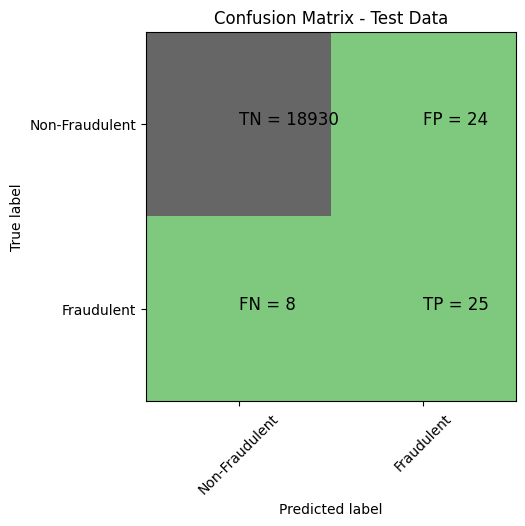

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       0.51      0.76      0.61        33

    accuracy                           1.00     18987
   macro avg       0.75      0.88      0.80     18987
weighted avg       1.00      1.00      1.00     18987

gini tree_roc_value: 0.8781547670436559
Tree threshold: 1.0
ROC for the test dataset 87.8%


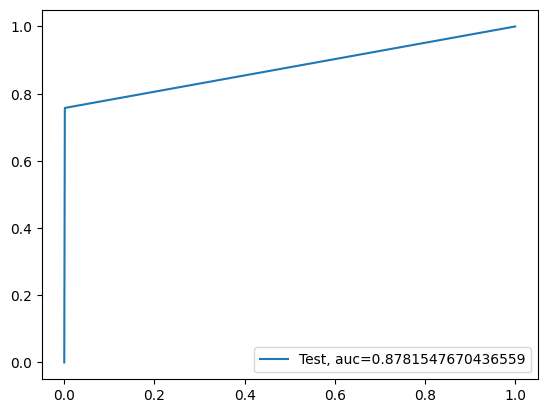

entropy score: 0.9985253067888555
Precision: 0.5581395348837209
Recall: 0.7272727272727273
F1 Score: 0.631578947368421
Confusion Matrix


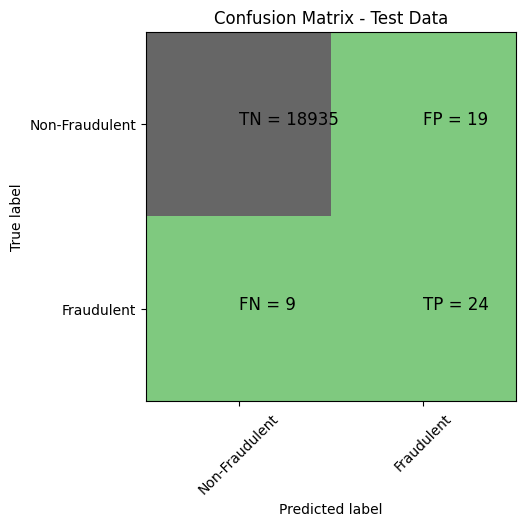

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       0.56      0.73      0.63        33

    accuracy                           1.00     18987
   macro avg       0.78      0.86      0.82     18987
weighted avg       1.00      1.00      1.00     18987

entropy tree_roc_value: 0.8631351501721873
Tree threshold: 1.0
ROC for the test dataset 86.3%


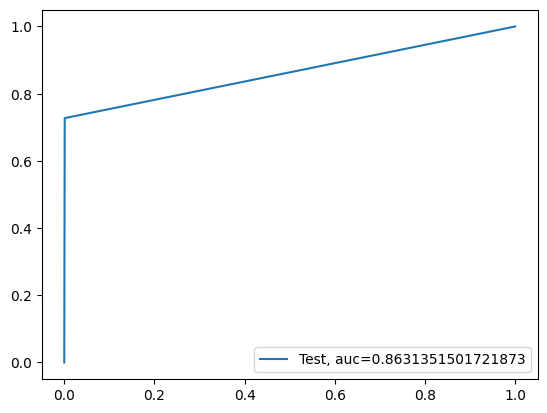

Time Taken by Model: --- 25.836551189422607 seconds --- 
--------------------------------------------------------------------------------
Random Forest Model
Model Accuracy: 0.9995259914678464
Precision: 0.9615384615384616
Recall: 0.7575757575757576
F1 Score: 0.847457627118644
Confusion Matrix


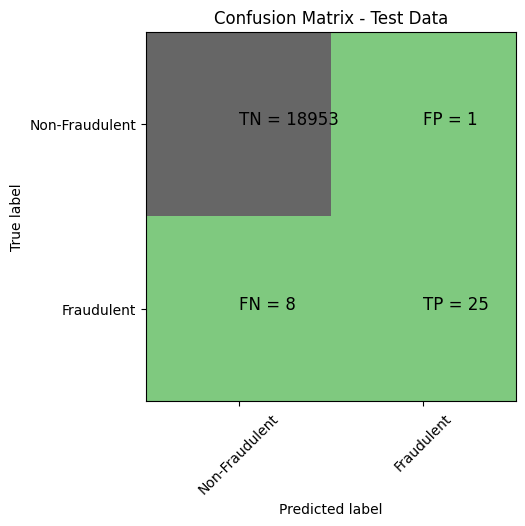

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       0.96      0.76      0.85        33

    accuracy                           1.00     18987
   macro avg       0.98      0.88      0.92     18987
weighted avg       1.00      1.00      1.00     18987

Random Forest roc_value: 0.9797652050738471
Random Forest threshold: 0.03
ROC for the test dataset 98.0%


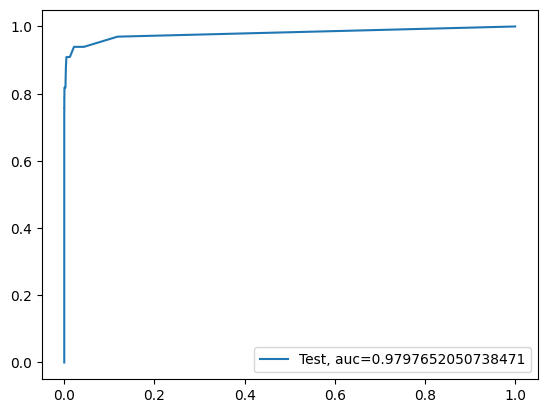

Time Taken by Model: --- 147.08025550842285 seconds --- 
--------------------------------------------------------------------------------
XGBoost Model
Model Accuracy: 0.999420656238479
Precision: 0.8666666666666667
Recall: 0.7878787878787878
F1 Score: 0.8253968253968254
Confusion Matrix


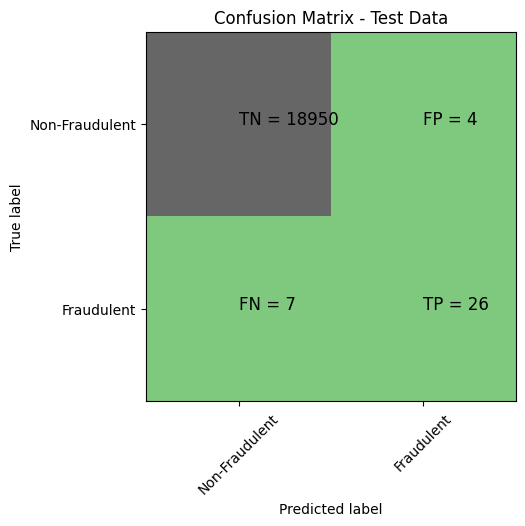

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18954
           1       0.87      0.79      0.83        33

    accuracy                           1.00     18987
   macro avg       0.93      0.89      0.91     18987
weighted avg       1.00      1.00      1.00     18987

XGBoost roc_value: 0.9737034798763193
XGBoost threshold: 6.47788037895225e-05
ROC for the test dataset 97.4%


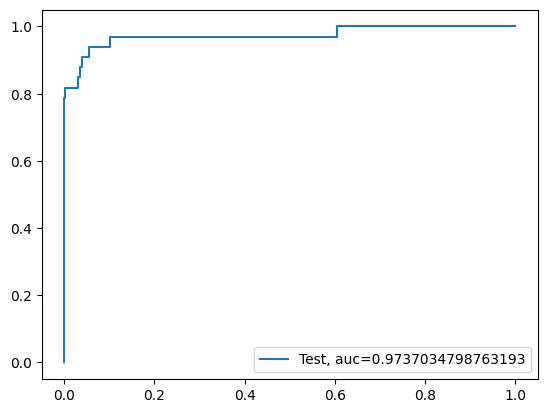

Time Taken by Model: --- 4.681506156921387 seconds --- 
--------------------------------------------------------------------------------


In [62]:
Data_Imbalance_Handiling = "ADASYN Oversampling with StratifiedKFold CV"

# Run Logistic Regression with L1 And L2 Regularisation
print("Logistic Regression with L1 And L2 Regularisation")
start_time = time.time()
df_Results = buildAndRunLogisticModels(
    df_Results, Data_Imbalance_Handiling, X_train_ADASYN, y_train_ADASYN, X_test, y_test
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 80)

# Run KNN Model
print("KNN Model")
start_time = time.time()
df_Results = buildAndRunKNNModels(
    df_Results, Data_Imbalance_Handiling, X_train_ADASYN, y_train_ADASYN, X_test, y_test
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 80)

# Run Decision Tree Models with 'gini' & 'entropy' criteria
print("Decision Tree Models with 'gini' & 'entropy' criteria")
start_time = time.time()
df_Results = buildAndRunTreeModels(
    df_Results, Data_Imbalance_Handiling, X_train_ADASYN, y_train_ADASYN, X_test, y_test
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 80)

# Run Random Forest Model
print("Random Forest Model")
start_time = time.time()
df_Results = buildAndRunRandomForestModels(
    df_Results, Data_Imbalance_Handiling, X_train_ADASYN, y_train_ADASYN, X_test, y_test
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 80)

# Run XGBoost Model
print("XGBoost Model")
start_time = time.time()
df_Results = buildAndRunXGBoostModels(
    df_Results, Data_Imbalance_Handiling, X_train_ADASYN, y_train_ADASYN, X_test, y_test
)
print("Time Taken by Model: --- %s seconds --- " % (time.time() - start_time))
print('-' * 80)

In [63]:
# Checking the df_result dataframe which contains consolidated results of all the runs
df_Results

,Methodology,Model,Accuracy,roc_value,threshold,Precision,Recall,F1
0,RepeatedKFold Cross Validation,Logistic Regression with L1 Regularisation,0.999315,0.958522,0.004442,0.923077,0.685714,0.786885
1,RepeatedKFold Cross Validation,Logistic Regression with L2 Regularisation,0.998999,0.979524,0.001238,0.863636,0.542857,0.666667
2,RepeatedKFold Cross Validation,KNN,0.999052,0.871264,0.200000,0.904762,0.542857,0.678571
3,RepeatedKFold Cross Validation,Tree Model with gini criteria,0.999105,0.885477,1.000000,0.750000,0.771429,0.760563
4,RepeatedKFold Cross Validation,Tree Model with entropy criteria,0.999210,0.857011,1.000000,0.833333,0.714286,0.769231
5,RepeatedKFold Cross Validation,Random Forest,0.999315,0.912004,0.010000,0.866667,0.742857,0.800000
6,RepeatedKFold Cross Validation,XGBoost,0.995576,0.418296,0.999999,0.019608,0.028571,0.023256
7,RepeatedKFold Cross Validation,SVM,0.997472,0.668665,0.001576,0.066667,0.028571,0.040000
8,StratifiedKFold Cross Validation,Logistic Regression with L1 Regularisation,0.999263,0.983288,0.003109,0.913043,0.636364,0.750000
9,StratifiedKFold Cross Validation,Logistic Regression with L2 Regularisation,0.998894,0.993220,0.001488,0.928571,0.393939,0.553191


Results for ADASYN Oversampling with StratifiedKFold:


Looking at Accuracy and ROC value we have XGBoost which has provided best results for ADASYN Oversampling with StratifiedKFold technique

**Overall conclusion after running the models on Oversampled data :**


Looking at above results it seems XGBOOST model with Random Oversampling with StratifiedKFold CV has provided the best results under the category of
all oversampling techniques. So we will try to tune the hyperparameters of this model to get best results.



---
**Hyperparameter Tuning**



HPT -- XgBoost Regression

In [64]:
# Performing Hyperparameter tuning
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

param_test = {
    'max_depth': range(3, 10, 2),
    'min_child_weight': range(1, 6, 2),
    'n_estimators': range(60, 130, 15),
    'learning_rate': [0.05, 0.1, 0.125, 0.15, 0.2],
    'gamma': [i / 10.0 for i in range(0, 5)],
    'subsample': [i / 10.0 for i in range(7, 10)],
    'colsample_bytree': [i / 10.0 for i in range(7, 10)]
}

gsearch1 = RandomizedSearchCV(
    estimator=XGBClassifier(
        base_score=0.5,
        booster='gbtree',
        colsample_bylevel=1,
        colsample_bynode=1,
        max_delta_step=0,
        missing=None,
        n_jobs=-1,
        nthread=None,
        objective='binary:logistic',
        random_state=42,
        reg_alpha=0,
        reg_lambda=1,
        scale_pos_weight=1,
        seed=None,
        silent=None,
        verbosity=1
    ),
    param_distributions=param_test,
    n_iter=5,
    scoring='roc_auc',
    n_jobs=-1,
    cv=5
)

gsearch1.fit(X_over, y_over)

gsearch1.cv_results_, gsearch1.best_params_, gsearch1.best_score_

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan]
  warnings.warn(


({'mean_fit_time': array([3.74051547, 3.26001835, 3.79449296, 2.98087673, 3.50992117]),
  'std_fit_time': array([0.51475238, 0.45390005, 0.78575288, 0.06450473, 1.02352273]),
  'mean_score_time': array([0.02120867, 0.01051512, 0.01366429, 0.01270528, 0.0097187 ]),
  'std_score_time': array([0.01197634, 0.0012328 , 0.00455777, 0.00446436, 0.00193982]),
  'param_subsample': masked_array(data=[0.7, 0.8, 0.7, 0.8, 0.9],
               mask=[False, False, False, False, False],
         fill_value=1e+20),
  'param_n_estimators': masked_array(data=[105, 120, 120, 120, 90],
               mask=[False, False, False, False, False],
         fill_value=999999),
  'param_min_child_weight': masked_array(data=[5, 1, 1, 1, 5],
               mask=[False, False, False, False, False],
         fill_value=999999),
  'param_max_depth': masked_array(data=[5, 3, 3, 3, 5],
               mask=[False, False, False, False, False],
         fill_value=999999),
  'param_learning_rate': masked_array(data=[0.2, 0

Please note that the hyperparameters found above using RandomizedSearchCV and the hyperparameters used below in creating the final model might be
different, the reason being, I have executed the RandomizedSearchCV multiple times to find which set of hyperparameters gives the optimum result and finally
used the one below which gave me the best performance.

In [66]:
# Creating XGBoost model with selected hyperparameters
from xgboost import XGBClassifier

clf = XGBClassifier(
    base_score=0.5,
    booster='gbtree',
    colsample_bylevel=1,
    colsample_bynode=1,
    colsample_bytree=0.7,
    gamma=0.2,
    learning_rate=0.125,
    max_delta_step=0,
    max_depth=7,
    min_child_weight=5,
    n_estimators=60,
    n_jobs=-1,
    objective='binary:logistic',
    random_state=42,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=1,
    subsample=0.8,
    verbosity=1
)

# Fit on the dataset
clf.fit(X_over, y_over)

# Predictions
y_pred = clf.predict(X_test)

# Accuracy
XGB_test_score = clf.score(X_test, y_test)
print('Model Accuracy: {0}'.format(XGB_test_score))

# Precision, Recall and F1 Score
XGB_Precision = metrics.precision_score(y_test, y_pred, zero_division=0)
XGB_Recall = metrics.recall_score(y_test, y_pred, zero_division=0)
XGB_F1 = metrics.f1_score(y_test, y_pred, zero_division=0)

print("Precision:", XGB_Precision)
print("Recall:", XGB_Recall)
print("F1 Score:", XGB_F1)

# Probabilities for each class
XGB_probs = clf.predict_proba(X_test)[:, 1]

# Calculate ROC AUC
XGB_roc_value = roc_auc_score(y_test, XGB_probs)

print("XGBoost roc_value: {0}".format(XGB_roc_value))
fpr, tpr, thresholds = metrics.roc_curve(y_test, XGB_probs)
threshold = thresholds[np.argmax(tpr - fpr)]

print("XGBoost threshold: {0}".format(threshold))

Model Accuracy: 0.9994733238531627
Precision: 0.896551724137931
Recall: 0.7878787878787878
F1 Score: 0.8387096774193549
XGBoost roc_value: 0.980582974410135
XGBoost threshold: 0.0039329128339886665


**Printing the important features of the best model to understand the dataset**

In [67]:
imp_var = []

for i in clf.feature_importances_:
  imp_var.append(i)

print('Top var =', imp_var.index(np.sort(clf.feature_importances_)[-1]) + 1)
print('2nd Top var =', imp_var.index(np.sort(clf.feature_importances_)[-2]) + 1)
print('3rd Top var =', imp_var.index(np.sort(clf.feature_importances_)[-3]) + 1)

Top var = 14
2nd Top var = 10
3rd Top var = 17


In [68]:
XGB_roc_value = roc_auc_score(y_test, XGB_probs)

print("XGBoost roc_value: {0}".format(XGB_roc_value))
fpr, tpr, thresholds = metrics.roc_curve(y_test, XGB_probs)
threshold = thresholds[np.argmax(tpr - fpr)]
print("XGBoost threshold: {0}".format(threshold))

XGBoost roc_value: 0.980582974410135
XGBoost threshold: 0.0039329128339886665


**Conclusion**

Among the oversampling approaches, we found that the XGBoost model with Random Oversampling and StratifiedKFold CV gave the best accuracy and ROC-AUC on the oversampled data.

After performing hyperparameter tuning, we obtained the following metrics:

XGBoost ROC-AUC: 0.980582974410135

XGBoost Threshold: 0.0039329128339886665

However, among all the models evaluated, Logistic Regression with L2 Regularisation using StratifiedKFold Cross Validation, without any oversampling or undersampling, gave the best overall results.